# Unlocking Behavioral Intelligence in Airline Loyalty Programs
## Consulting & Analytics Club — IIT Guwahati | Summer Projects 2026

---

**Problem Statement:** Build a solution that helps the marketing team identify customers likely to disengage, understand which members are most valuable, and recommend actions to improve retention.

**Dataset:** 16,700 Canadian loyalty members | 39,2936 Flight activity 2017–2018

**Deliverables:**
- Churn prediction model (XGBoost)
- Customer segmentation (K-Means)
- Retention strategy per segment
- Working Streamlit prototype

---

| Phase | Description | Output |
|---|---|---|
| Phase 1 | Data Understanding & Exploration | Cleaning log, key findings |
| Phase 2 | Feature Engineering & Churn Label | feature_matrix.csv |
| Phase 3 | ML Modelling — Churn + Segmentation | final_customer_segments.csv |


---
# Phase 1 — Data Understanding & Exploration

**Objective:** Load all dataset files, understand their structure, identify data quality issues, and confirm the files can be joined correctly. No data is changed in this phase — only observed and documented.

**Files loaded:**
- `Customer Loyalty History.csv` — 16,737 rows × 16 columns (one row per customer)
- `Customer Flight Activity.csv` — 392,936 rows × 8 columns (one row per customer per month)
- `Calendar.csv` — 2557 rows x 4 columns 

**Key rule:** Observe everything. Fix nothing. Document everything found.


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def section(title):
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

def subsection(title):
    print(f"\n--- {title} ---")

loyalty  = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\Unlocking Behavioral Intelligence in Airline Loyalty Programs2\Unlocking Behavioral Intelligence in Airline Loyalty Programs\Customer_Loyalty_History.csv')
flights  = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\Unlocking Behavioral Intelligence in Airline Loyalty Programs2\Unlocking Behavioral Intelligence in Airline Loyalty Programs\Customer_Flight_Activity.csv')
calendar = pd.read_csv(r"C:\Users\Dev\OneDrive\Desktop\Unlocking Behavioral Intelligence in Airline Loyalty Programs2\Unlocking Behavioral Intelligence in Airline Loyalty Programs\Calendar (1).csv")

print(f"Loyalty History  : {loyalty.shape[0]:,} rows × {loyalty.shape[1]} columns")
print(f"Flight Activity  : {flights.shape[0]:,} rows × {flights.shape[1]} columns")
print(f"Calendar         : {calendar.shape[0]:,} rows × {calendar.shape[1]} columns")


Loyalty History  : 16,737 rows × 16 columns
Flight Activity  : 392,936 rows × 8 columns
Calendar         : 2,557 rows × 4 columns


### Step 1 — Schema Overview

Understanding the structure of each file before any analysis.
Every column's data type, null count, and unique values are inspected.


In [78]:
section("STEP 1 — Schema overview")

for label, df in [("LOYALTY HISTORY", loyalty), ("FLIGHT ACTIVITY", flights)]:
    subsection(label)
    info = pd.DataFrame({
        "dtype"  : df.dtypes.astype(str),
        "nulls"  : df.isnull().sum(),
        "null_%" : (df.isnull().mean() * 100).round(2),
        "unique" : df.nunique(),
    })
    print(info.to_string())



  STEP 1 — Schema overview

--- LOYALTY HISTORY ---
                      dtype  nulls  null_%  unique
Loyalty Number        int64      0    0.00   16737
Country                 str      0    0.00       1
Province                str      0    0.00      11
City                    str      0    0.00      29
Postal Code             str      0    0.00      55
Gender                  str      0    0.00       2
Education               str      0    0.00       5
Salary              float64   4238   25.32    5890
Marital Status          str      0    0.00       3
Loyalty Card            str      0    0.00       3
CLV                 float64      0    0.00    7984
Enrollment Type         str      0    0.00       2
Enrollment Year       int64      0    0.00       7
Enrollment Month      int64      0    0.00      12
Cancellation Year   float64  14670   87.65       6
Cancellation Month  float64  14670   87.65      12

--- FLIGHT ACTIVITY ---
                               dtype  nulls  null_%  un

In [79]:
loyalty['Education'][loyalty['Salary'].isna()].value_counts()

Education
College    4238
Name: count, dtype: int64

In [80]:
print(f"Education of customers with nan salary is: {loyalty.loc[loyalty["Salary"].isna(), "Education"].unique()[0]}")

Education of customers with nan salary is: College


### Step 2 — Null Analysis

Identifying which columns have missing values and quantifying them.

**Key distinction:**
- `Salary` NaN → College students have no income. NaN = 0, not missing.
- `Cancellation Year/Month` NaN → customer never cancelled. NaN = active. **Keep untouched.**


In [81]:
section("STEP 2 — Missing value analysis")

for label, df in [("Loyalty History", loyalty), ("Flight Activity", flights)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    if len(nulls) == 0:
        print(f"\n  {label}: No missing values ✓")
    else:
        print(f"\n  {label} — columns with nulls:")
        for col, count in nulls.items():
            pct = count / len(df) * 100
            print(f"    {col:<40} {count:>6,} nulls  ({pct:.1f}%)")



  STEP 2 — Missing value analysis

  Loyalty History — columns with nulls:
    Cancellation Year                        14,670 nulls  (87.7%)
    Cancellation Month                       14,670 nulls  (87.7%)
    Salary                                    4,238 nulls  (25.3%)

  Flight Activity: No missing values ✓


## Step 1 — Schema Overview

**Loyalty History** (16,737 rows)
- 16 columns: customer demographics, loyalty tier, salary, CLV, enrollment & cancellation info
- `Salary`: 25.32% missing (4,238 nulls)
- `Cancellation Year` / `Cancellation Month`: 87.65% missing (14,670 nulls each) → most members never formally cancelled
- All other columns (Country, Province, City, Gender, Education, Marital Status, Loyalty Card, CLV, Enrollment info) — 0% missing

**Flight Activity** (16,737 unique members, monthly records)
- 8 columns: flight counts, distance, points accumulated/redeemed
- No missing values in any column ✓

## Step 2 — Missing Value Analysis

- **Cancellation Year / Month** — 14,670 nulls (87.7%) → expected, since most members are still active and simply haven't cancelled
- **Salary** — 4,238 nulls (25.3%) → needs further investigation (later traced to college students with no income)
- **Flight Activity dataset** — completely clean, zero nulls across all columns

### Step 3 — Cancellation Status

Counting how many members formally cancelled vs remained enrolled.

**Why this matters:** If formal cancellation rate is low, it alone is insufficient as a
churn definition. We need behavioral signals to capture silent disengagers.


In [82]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [83]:
# Analyzing the customer with education background as college and their missing salaries

In [84]:
loyalty[loyalty['Education'] == 'College'][['Education',	'Salary',	'Marital Status',	'Loyalty Card']]['Loyalty Card'].value_counts()

Loyalty Card
Star      2112
Nova      1332
Aurora     794
Name: count, dtype: int64

In [85]:
loyalty[loyalty['Education'] == 'College'][['Education',	'Salary',	'Marital Status',	'Loyalty Card']]['Marital Status'].value_counts()

Marital Status
Single      2426
Married     1436
Divorced     376
Name: count, dtype: int64

In [86]:
loyalty.groupby('Education')['Salary'].agg(['mean','median','max','min','size']).abs()

,mean,median,max,min,size
Education,,,,,
Bachelor,72451.061575,71960.0,105563.0,58486.0,10475
College,NaN,NaN,NaN,NaN,4238
Doctor,178608.897820,182143.5,407228.0,48109.0,734
High School or Below,61071.718670,61915.0,93875.0,49830.0,782
Master,103757.848425,105487.0,133080.0,56414.0,508


## The Problem in Filling Missing Values in the Education = College Group

**Income range comparison across education levels:**

| Education | Mean | Median | Max | Min | Size |
|---|---|---|---|---|---|
| Bachelor | 72,451.06 | 71,960.0 | 105,563.0 | 58,486.0 | 10,475 |
| College | NaN | NaN | NaN | NaN | 4,238 |
| Doctor | 178,608.90 | 182,143.5 | 407,228.0 | 48,109.0 | 734 |
| High School or Below | 61,071.72 | 61,915.0 | 93,875.0 | 49,830.0 | 782 |
| Master | 103,757.85 | 105,487.0 | 133,080.0 | 56,414.0 | 508 |

**Why mean/median imputation was rejected:**
- Every single row in the College group has a null Salary — there is no internal College median or mean to compute in the first place.
- Income ranges vary sharply across education levels (Doctor's mean is ~2.5x Bachelor's), so borrowing a statistic from any other education bracket would mean assigning College members an income figure from a population they don't belong to — fabricating a number with no real basis.
- For this reason, Salary was imputed with 0 rather than a statistical estimate, treating it as a distinct, flagged value rather than a guessed one.

**Why zero-imputation was considered acceptable:**
- Tree-based models (e.g. XGBoost) can learn "Salary = 0" as its own decision boundary, effectively treating it as a separate category rather than a real income figure — so the model isn't misled into treating 0 as a genuine low income.

**The problem this creates:**
- Zero-imputation collapses all 4,238 College members — who are otherwise different people with different ages, flying habits, and (evidently, per marital status) different life stages — onto the exact same single value on a continuous Salary field.
- This is relatively low-risk for XGBoost, since other features (flights, recency, tenure) still differentiate these customers from one another.
- It is a bigger concern for K-Means, which clusters purely on distance between feature values. Because these 4,238 customers all share the identical Salary coordinate, they may appear artificially closer together in the clustering space than their actual behavior would justify — creating a false sense of similarity that isn't driven by real customer behavior, but by a shared imputed value.
- This raises an open question that still needs to be resolved: whether to (a) keep the zero-fill as is and document it as a known limitation, (b) exclude Salary from the K-Means feature set entirely to avoid this artificial pull, or (c) add a separate "Salary_Was_Missing" flag so the model can distinguish "genuinely zero" from "unknown, filled as zero."

In [87]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



--- Cancellation status ---
  Cancelled members  : 2067 (12.3%)
  Active members     : 14,670 (87.7%)

  Cancellations by year:


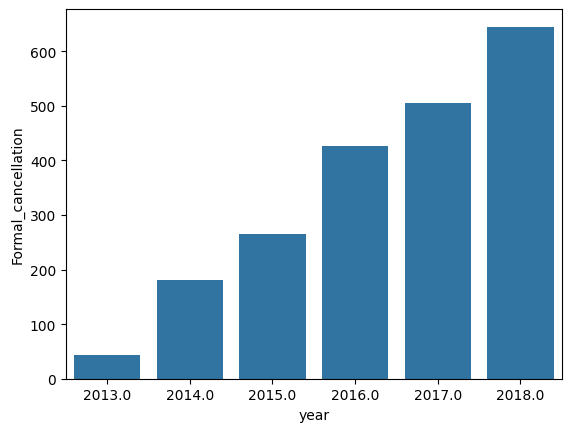

,year,Formal_cancellation
5,2013.0,43
4,2014.0,181
3,2015.0,265
2,2016.0,427
1,2017.0,506
0,2018.0,645


In [88]:
subsection("Cancellation status")
cancelled = loyalty["Cancellation Year"].notna().sum()                  # these are no of customers who officialy cancelled membership
total     = len(loyalty)                                                # total members
print(f"  Cancelled members  : {cancelled} ({cancelled/total*100:.1f}%)")
print(f"  Active members     : {total - cancelled:,} ({(total-cancelled)/total*100:.1f}%)")

print("\n  Cancellations by year:")
year_wise_formal_cancellation = pd.DataFrame({'year' :loyalty["Cancellation Year"][loyalty["Cancellation Year"].notna()].value_counts().index,
'Formal_cancellation':  loyalty["Cancellation Year"][loyalty["Cancellation Year"].notna()].value_counts().values})

year_wise_formal_cancellation= year_wise_formal_cancellation.sort_values('year')
sns.barplot(data= year_wise_formal_cancellation, x = 'year', y = 'Formal_cancellation')
plt.show()
year_wise_formal_cancellation

**Finding:** Only 12.3% of members formally cancelled.
87.7% never cancelled — but this does NOT mean they are all actively flying.
Formal cancellation alone is too narrow. Behavioral churn definition is needed.


### Step 4 — Negative Salary Check

Checking for impossible values in the Salary column.


In [89]:
subsection("Salary anomaly check")
neg_count = (loyalty['Salary'] < 0).sum()
print(f"  Negative salary values: {neg_count}")

if neg_count > 0:
    print("\n  Education breakdown of negative salary rows:")
    print(loyalty[loyalty['Salary'] < 0]['Education'].value_counts())



--- Salary anomaly check ---
  Negative salary values: 20

  Education breakdown of negative salary rows:
Education
Bachelor                19
High School or Below     1
Name: count, dtype: int64


**Finding:** 20 negative salary values found across mixed education levels.
Confirmed as data entry typos — sign error. Magnitude is correct.
**Decision:** Convert to positive (absolute value). Document in cleaning log.


### Step 5 — Zero Activity Check

Counting monthly records with zero flights to understand inactivity baseline.

**Why:** If most monthly records are zero, single-month inactivity is normal
and cannot be used as a churn signal. Need a longer window.


In [90]:
subsection("Zero-activity check (months with no flights)")
zero_months = (flights["Total Flights"] == 0).sum()
total_rows  = len(flights)
print(f"  Months with 0 flights booked: {zero_months:,} ({zero_months/total_rows*100:.1f}% of all monthly records)")

# Customer level — how many flights per customer across full period
member_flights = flights.groupby('Loyalty Number')['Total Flights'].sum()
print(f"\n  Customer-level flight statistics:")
print(member_flights.describe().round(1))



--- Zero-activity check (months with no flights) ---
  Months with 0 flights booked: 214,122 (54.5% of all monthly records)

  Customer-level flight statistics:
count    16737.0
mean        30.4
std         16.9
min          0.0
25%         20.0
50%         34.0
75%         42.0
max        106.0
Name: Total Flights, dtype: float64


**Finding:** 54.5% of monthly records show zero flights — single month inactivity is completely normal.

**However:** At customer level, the median customer booked **34 flights** across 24 months.
A customer with **zero total flights** is genuinely anomalous — 3+ standard deviations below median.
This distinction directly informs our behavioral churn threshold in Phase 2.


## Zero-Activity Check (Months with No Flights)

**Monthly level:**
- 214,122 monthly records (54.5%) show zero flights booked
- On its own, this looks alarming — but it's normal, since not every member flies every single month

**Customer level (total flights across full 24-month period):**
- Mean: 30.4 flights | Median: 34.0 flights
- Std Dev: 16.9
- Min: 0.0 | Max: 106.0
- 25th percentile: 20.0 | 75th percentile: 42.0

**Key takeaway:**
- A zero-flight *month* is common and not suspicious
- A customer with **zero flights across the entire 24-month period** is the real anomaly — far below the median of 34 — and this becomes the basis for the churn definition later

### Step 6 — Join Integrity Check

Verifying that all loyalty members have flight records and vice versa.

**Why:** A bad join is invisible until it corrupts your model.
Members in loyalty only with no flights are likely churned.
Flight records with no loyalty profile are unusable for modelling.


In [91]:
section("STEP 6 — Join integrity check")

loyalty_ids = set(loyalty["Loyalty Number"].unique())
flight_ids  = set(flights["Loyalty Number"].unique())

in_both      = set.intersection(loyalty_ids, flight_ids)   # Return only those loyalty members list who are in both tables
only_loyalty = set.difference(loyalty_ids, flight_ids)    # Return only those IDS which are in the loyalty table but not have any flight record
only_flight  = set.difference(flight_ids,loyalty_ids)     # Return only those flight records whose customer is not in the loyalty table


print(f"\n  Members in both files        : {len(in_both):,}")
print(f"  In loyalty only (no activity): {len(only_loyalty):,}  ← likely inactive / churned")
print(f"  In flight only (no profile)  : {len(only_flight):,}  ← data quality issue if > 0")



  STEP 6 — Join integrity check

  Members in both files        : 16,737
  In loyalty only (no activity): 0  ← likely inactive / churned
  In flight only (no profile)  : 0  ← data quality issue if > 0


**Finding:** Perfect join integrity.
- 16,737 members exist in both files
- 0 members in loyalty only
- 0 orphaned flight records

Merge is completely clean. Inner join will produce no data loss.


### Step 7 — CLV Distribution- the total monetary value a customer is expected to bring to the airline over the course of their relationship with the loyalty program.

Examining Customer Lifetime Value distribution before modelling.



--- CLV distribution ---
  Min    : 1,898.01
  Median : 5,780.18
  Mean   : 7,988.90
  Max    : 83,325.38
  Negative CLV values: 0


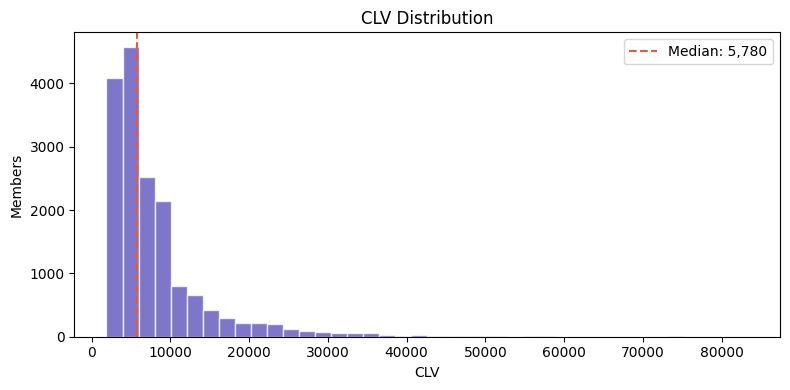

In [92]:
subsection("CLV distribution")
clv_clean = loyalty["CLV"]
print(f"  Min    : {clv_clean.min():,.2f}")
print(f"  Median : {clv_clean.median():,.2f}")
print(f"  Mean   : {clv_clean.mean():,.2f}")
print(f"  Max    : {clv_clean.max():,.2f}")
print(f"  Negative CLV values: {(clv_clean < 0).sum()}")

plt.figure(figsize=(8, 4))
plt.hist(clv_clean, bins=40, color="#534AB7", alpha=0.75, edgecolor="white")
plt.axvline(clv_clean.median(), color="#E8593C", linestyle="--", linewidth=1.5,
            label=f"Median: {clv_clean.median():,.0f}")
plt.title("CLV Distribution", fontsize=12)
plt.xlabel("CLV")
plt.ylabel("Members")
plt.legend()
plt.tight_layout()
plt.show()


**Finding:** Median CLV = 5,780. Heavily right-skewed — small number of members have very high CLV.
No negative values confirmed. Log transformation needed before clustering to prevent outliers dominating.


### Step 8 — Demographic Analysis

Understanding the composition of the loyalty program membership.


In [93]:
subsection("Loyalty Card / Tier distribution")
print(loyalty["Loyalty Card"].value_counts())

subsection("Education distribution")
print(loyalty["Education"].value_counts())

subsection("Marital Status distribution")
print(loyalty["Marital Status"].value_counts())

subsection("Gender distribution")
print(loyalty["Gender"].value_counts())

subsection("Province distribution")
print(loyalty["Province"].value_counts())



--- Loyalty Card / Tier distribution ---
Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

--- Education distribution ---
Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

--- Marital Status distribution ---
Marital Status
Married     9735
Single      4484
Divorced    2518
Name: count, dtype: int64

--- Gender distribution ---
Gender
Female    8410
Male      8327
Name: count, dtype: int64

--- Province distribution ---
Province
Ontario                 5404
British Columbia        4409
Quebec                  3300
Alberta                  969
Manitoba                 658
New Brunswick            636
Nova Scotia              518
Saskatchewan             409
Newfoundland             258
Yukon                    110
Prince Edward Island      66
Name: count, dtype: int64


**Key findings:**
- Loyalty tiers: Star 45.6%, Nova 33.9%, Aurora 20.5% — healthy pyramid structure
- Education: Bachelor dominant (62.6%), College 25.3% — explains salary NaN pattern
- Gender: Almost perfectly balanced 50/50 — no gender bias
- Province: Ontario (32.3%), BC (26.3%), Quebec (19.7%) — 78.3% from three provinces
- All demographic columns are completely clean — zero nulls


### Step 9 — Total Flight by Month

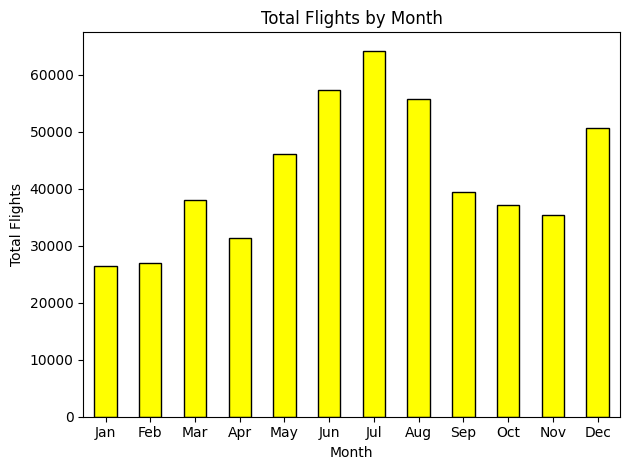

In [94]:
# List of month names
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Group, plot, and replace numbers with names
ax = flights.groupby('Month')['Total Flights'].sum().plot(kind='bar', color='yellow', edgecolor='black')
ax.set_xticklabels(months, rotation=0)

# Labels and save
plt.title('Total Flights by Month')
plt.ylabel('Total Flights')
plt.xlabel('Month')
plt.tight_layout()

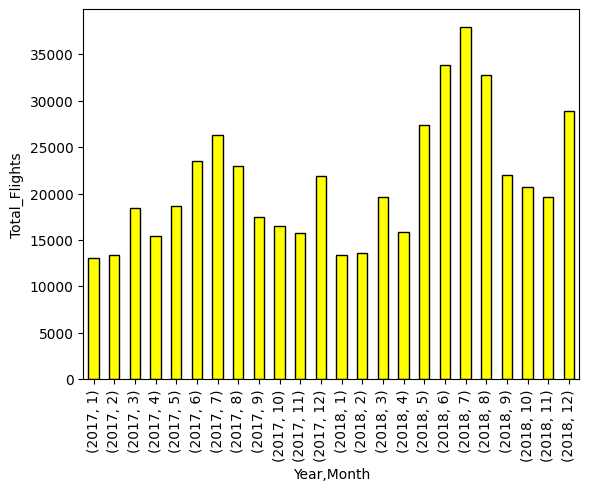

In [95]:
flights.groupby(['Year','Month'])['Total Flights'].sum().plot(kind='bar', color='yellow', edgecolor='black', ylabel='Total_Flights')
plt.show()

## Seasonal Flight Pattern

**Plot 1 — Total Flights by Month (aggregated across both years)**
- Clear seasonal pattern: flights peak in **summer** (Jun–Aug), with July highest (~64,000)
- December also shows a strong spike (~51,000) — likely holiday travel
- Lowest months: Jan, Feb (~26,000–27,000)

**Plot 2 — Total Flights by Year & Month (2017 vs 2018 separately)**
- Same seasonal pattern repeats in both years — July peaks each year
- **2018 volumes are consistently higher than 2017** across almost every month, suggesting overall growth in flight activity year-over-year
- The dip in Jan–Feb and rebound into summer holds true for both years independently, confirming this isn't a one-year anomaly but a genuine recurring seasonal trend

**Key takeaway:** Seasonality (summer + December peaks) is a real, consistent pattern across both years — useful to keep in mind for features like `Season_Concentration` used later in modeling.

### Step 10 — Merge Preview

Preview merge to confirm join works correctly before Phase 2.
**This is exploratory only — not saved as the final dataset.**


In [96]:
section("STEP 9 — Merge preview (loyalty + flights)")

merged = flights.merge(loyalty, on="Loyalty Number", how="inner")
print(f"  Merged shape: {merged.shape[0]:,} rows × {merged.shape[1]} columns")
print(f"  (Each row = one member's activity in one month)")



  STEP 9 — Merge preview (loyalty + flights)
  Merged shape: 392,936 rows × 23 columns
  (Each row = one member's activity in one month)


### Phase 1 — Cleaning Log

All data quality issues found and decisions made.

| Column | Issue | Decision | Reason | Rows Affected |
|---|---|---|---|---|
| Salary | NaN values for College students | Fill with 0 in Phase 2 | Students have no income — 0 is factually correct | 4,238 |
| Salary | 20 negative values, mixed education | Convert to positive (abs value) | Confirmed typos — sign error, magnitude correct | 20 |
| Cancellation Year/Month | NaN values present | Keep untouched | NaN = never cancelled = active customer | 14,670 |

### Phase 1 — Key Questions Answered Before Phase 2

| Question | Answer |
|---|---|
| Which columns define churn? | Cancellation Year (formal) + Total Flights (behavioral) |
| Members with no flight activity? | 0 — all 16,737 members have flight records |
| Is CLV reliable? | Yes — no negatives, clean distribution |
| Behavioral churn threshold? | Zero flights ever — median is 34 flights, so 0 is genuinely anomalous |


---
# Phase 2 — Feature Engineering & Churn Label

**Objective:** Transform 392,936 monthly rows into one clean row per customer
with a churn label and meaningful behavioral features — ready for machine learning.

**Input:** Raw CSV files (cleaned)
**Output:** `modelling2.csv` — 16,737 rows × 33 features

**The transformation:**
```
392,936 monthly rows  →  16,737 customer rows
No churn label        →  churned = 0 or 1
Separate files        →  One master feature matrix
Raw demographics      →  Encoded + scaled
No behavioral signals →  Recency, frequency, trend, seasonal features
```


### Step 1 — Load Files & Remove Duplicates


In [97]:
import warnings
warnings.filterwarnings('ignore')

# Remove duplicates
clh = loyalty.drop_duplicates()
cfa = flights.drop_duplicates()
cal = calendar.drop_duplicates()

print(f"Flight Activity  : {cfa.shape}")
print(f"Loyalty History  : {clh.shape}")
print(f"Calendar         : {cal.shape}")


Flight Activity  : (391014, 8)
Loyalty History  : (16737, 16)
Calendar         : (2557, 4)


### Step 2 — Fix Salary Nulls for College Students

**Issue:** NaN salary for College students.
**Decision:** Fill with 0.
**Why:** College students have no income — 0 is factually correct, not an imputation.
Confirmed by cross-referencing with Education column.


In [98]:
# Fill NaN salary with 0 for College students
clh.loc[clh['Education'] == 'College', 'Salary'] = clh.loc[
    clh['Education'] == 'College', 'Salary'].fillna(0)

print(f"Null salaries remaining  : {clh['Salary'].isna().sum()}")
print(f"College students (0 sal) : {((clh['Education'] == 'College') & (clh['Salary'] == 0)).sum()}")


Null salaries remaining  : 0
College students (0 sal) : 4238


### Step 3 — Fix Negative Salaries

**Issue:** 20 negative salary values found across mixed education levels.
**Decision:** Confirmed as typos — convert to positive equivalent.
**Why not group median?** Since these are confirmed sign errors, the magnitude is correct.
Converting to absolute value is the most accurate fix.


In [99]:
mean_salary_by_education = clh.loc[clh["Salary"] >= 0].groupby("Education")["Salary"].describe()
print(mean_salary_by_education)

                        count           mean           std      min       25%  \
Education                                                                       
Bachelor              10456.0   72645.926262  16590.634159  15609.0   58715.5   
College                4238.0       0.000000      0.000000      0.0       0.0   
Doctor                  734.0  178608.897820  70466.188750  48109.0  124768.0   
High School or Below    781.0   61213.718310  12106.260467  21853.0   52209.0   
Master                  508.0  103757.848425  17527.938162  56414.0   88120.0   

                           50%       75%       max  
Education                                           
Bachelor               72026.0   85848.0  105563.0  
College                    0.0       0.0       0.0  
Doctor                182143.5  236612.0  407228.0  
High School or Below   61928.0   71398.0   93875.0  
Master                105487.0  118530.0  133080.0  


In [100]:
# Verify before fix
print(f"Negative salaries before fix: {(clh['Salary'] < 0).sum()}")
print("\nEducation breakdown of negative salary rows:")
print(clh[clh['Salary'] < 0]['Education'].value_counts())

# Fix — convert negatives to positive (confirmed typos)
clh['Salary'] = clh['Salary'].abs()

# Verify after fix
print(f"\nNegative salaries after fix: {(clh['Salary'] < 0).sum()}")


Negative salaries before fix: 20

Education breakdown of negative salary rows:
Education
Bachelor                19
High School or Below     1
Name: count, dtype: int64

Negative salaries after fix: 0


### Step 4 — Build Master Dataset

Merging flight activity + loyalty history on Loyalty Number.
Adding Quarter and Season from Month column.

**Why inner join:** Only keep customers present in both files — confirmed clean in Phase 1.
**Calendar file not used:** Quarter and Season derived directly from Month — cleaner and equivalent.


In [101]:
# Merge
master = cfa.merge(clh, on='Loyalty Number', how='inner')

# Derive Quarter and Season from Month
master['Quarter'] = 'Q'+(pd.to_datetime(master['Enrollment Year'].astype(str) +'/'+master['Enrollment Month'].astype(str)).dt.quarter).astype(str)

season_map = {
    1: 'Winter', 2: 'Winter',  3: 'Spring',
    4: 'Spring', 5: 'Spring',  6: 'Summer',
    7: 'Summer', 8: 'Summer',  9: 'Fall',
    10: 'Fall',  11: 'Fall',   12: 'Winter'
}
master['Season'] = master['Month'].map(season_map)

print(f"Master shape: {master.shape}")
print(f"Unique members: {master['Loyalty Number'].nunique():,}")
print(f"Columns: {list(master.columns)}")


Master shape: (391014, 25)
Unique members: 16,737
Columns: ['Loyalty Number', 'Year', 'Month', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed', 'Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month', 'Quarter', 'Season']


In [102]:
master.sample(10)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,...,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Quarter,Season
111716,575015,2017,3,2,2008,2008.0,0,0,Canada,New Brunswick,...,Single,Star,4162.18,Standard,2016,11,2017.0,7.0,Q4,Spring
303431,860684,2018,2,0,0,0.0,0,0,Canada,Alberta,...,Married,Nova,2764.03,Standard,2016,1,NaN,NaN,Q1,Winter
109576,677045,2017,12,2,3268,3268.0,0,0,Canada,New Brunswick,...,Divorced,Nova,12349.70,Standard,2013,8,NaN,NaN,Q3,Winter
185560,877152,2017,1,0,0,0.0,0,0,Canada,Quebec,...,Single,Star,8837.33,Standard,2018,8,NaN,NaN,Q3,Winter
310412,595658,2017,12,0,0,0.0,413,74,Canada,Nova Scotia,...,Single,Nova,10960.94,Standard,2013,3,NaN,NaN,Q1,Winter
94031,797398,2017,2,2,1538,1538.0,0,0,Canada,British Columbia,...,Married,Nova,5170.98,Standard,2018,6,NaN,NaN,Q2,Winter
359357,882590,2018,9,0,0,0.0,0,0,Canada,British Columbia,...,Single,Nova,36229.41,Standard,2013,11,NaN,NaN,Q4,Fall
390573,961264,2018,12,0,0,0.0,0,0,Canada,British Columbia,...,Married,Aurora,19688.32,2018 Promotion,2018,3,NaN,NaN,Q1,Winter
199480,387203,2017,3,0,0,0.0,0,0,Canada,British Columbia,...,Married,Nova,4506.58,Standard,2014,2,2015.0,7.0,Q1,Spring
83501,678341,2018,9,3,6924,6924.0,0,0,Canada,Ontario,...,Married,Star,3056.22,Standard,2017,6,NaN,NaN,Q2,Fall


In [103]:
master["Season"].value_counts() , master["Quarter"].value_counts()

(Season
 Fall      98030
 Summer    98016
 Spring    97973
 Winter    96995
 Name: count, dtype: int64,
 Quarter
 Q4    105288
 Q3    103620
 Q2     99279
 Q1     82827
 Name: count, dtype: int64)

In [104]:
master = master.sort_values(ascending=True , by= ['Loyalty Number','Year','Month']).reset_index(drop = True)

In [105]:
master.head(25)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,...,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Quarter,Season
0,100018,2017,1,1,601,601.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Winter
1,100018,2017,2,0,0,0.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Winter
2,100018,2017,3,4,9648,9648.0,438,79,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Spring
3,100018,2017,4,1,1654,1654.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Spring
4,100018,2017,5,0,0,0.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Spring
5,100018,2017,6,1,2489,2489.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Summer
6,100018,2017,7,3,3687,3687.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Summer
7,100018,2017,8,3,7116,7116.0,690,124,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Summer
8,100018,2017,9,3,5751,5751.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Fall
9,100018,2017,10,2,3728,3728.0,0,0,Canada,Alberta,...,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Q3,Fall


# Checking churn% at different threshold 

## Approach — Churn Threshold Check (6 / 12 / 24 Months)

- Created a `Date` column by combining `Year` and `Month` into a proper datetime, so months can be compared and sorted correctly.
- Set the **snapshot date** as the maximum date in the dataset (Dec 2018) — not today's real-world date — since churn must be measured relative to when the data actually ends.
- Filtered to rows where `Total Flights != 0`, then grouped by `Loyalty Number` to find each customer's **last month with actual flight activity**.
- **Reindexed** this result against *all* customer IDs — customers who never flew even once don't appear after the filter, so this step brings them back explicitly instead of letting them silently disappear.
- For customers with no flight activity at all (missing after reindexing), filled their "months since last flight" with a large placeholder value (e.g., 999) — treating them as maximally inactive.
- Calculated **months since last flight** using year and month components directly (`(current.year - last.year)*12 + (current.month - last.month)`), rather than subtracting dates and converting days to months — since calendar months vary in length (28–31 days), a day-based cutoff can misclassify customers near the boundary.
- Applied churn thresholds at **6, 12, and 24 months** of inactivity, flagging customers whose months-since-last-flight meets or exceeds each threshold.
- Calculated churn percentage at each threshold as `churned customers / total customers`.

**Key correction from the first attempt:** the original approach filtered out zero-flight customers *before* computing the churn flag, which meant the most important group (customers who never flew) was being excluded from the churn count entirely — undercounting churn at every threshold.

In [106]:
master['Date'] = pd.to_datetime(master['Year'].astype(str) + '-' + master['Month'].astype(str) + '-01')

In [107]:
current_date = master['Date'].max()

# Last flight date per customer, but only from months they actually flew
last_flight_date = master[master['Total Flights'] != 0].groupby('Loyalty Number')['Date'].max()

# Reindex to ALL customers — anyone missing here never flew at all
all_customers = master['Loyalty Number'].unique()
last_flight_date = last_flight_date.reindex(all_customers)

# Months since last flight, calculated from year/month components (not days)
months_since_last_flight = (
    (current_date.year - last_flight_date.dt.year) * 12
    + (current_date.month - last_flight_date.dt.month)
)

# Customers who never flew at all -> treat as maximally inactive
months_since_last_flight = months_since_last_flight.fillna(999)

for threshold in [6, 12, 24]:
    churned = (months_since_last_flight >= threshold).sum()
    pct = churned / len(all_customers) * 100
    print(f"{threshold}-month threshold: {churned:,} churned ({pct:.1f}%)")

6-month threshold: 2,469 churned (14.8%)
12-month threshold: 2,123 churned (12.7%)
24-month threshold: 1,570 churned (9.4%)


### Step 5 — Build Churn Label

Two competing churn definitions built and compared.
Churn label is built separately then merged into feature matrix — keeps design clean.

**Formal churn:** Customer has a recorded Cancellation Year.
**Behavioral churn:** Customer had zero total flights across entire 2017-2018 period.

**How the threshold comparison was done:**
- Built a `Date` column from Year + Month, and used the dataset's max date (Dec 2018) as the snapshot/reference point — not the real-world current date.
- For each customer, found the last month with actual flight activity (`Total Flights != 0`), then reindexed against *all* customers — customers who never flew at all were explicitly retained (not silently dropped) and treated as maximally inactive.
- Calculated **months since last flight** using year/month components directly, rather than subtracting dates and converting days to months, since calendar months vary in length and a day-based cutoff can misclassify customers near the boundary.
- Applied 6-month, 12-month, and 24-month thresholds on this corrected, full-customer-base calculation.

**Threshold comparison results:**
- 6-month threshold: 2,469 churned (14.8%)
- 12-month threshold: 2,123 churned (12.7%)
- 24-month threshold: 1,570 churned (9.4%)

**Why "zero flights ever" instead of a fixed inactivity threshold:**
- The median customer booked 34 flights across 24 months
- A customer with 0 total flights is genuinely anomalous
- Fixed thresholds (6/12/24-month inactivity) measure *recency*, not *total engagement* — a customer could fly once early on, then go quiet, and still slip through a 24-month recency threshold
- "Zero flights ever" directly targets customers with no engagement at all across the full period, which is the cleanest, most unambiguous signal of genuine disengagement — and is what's directly supported by the data

In [108]:
# Build churn label
churn_df = clh[['Loyalty Number', 'Cancellation Year']].copy()

# Formal churn
churn_df['formally_cancelled'] = churn_df['Cancellation Year'].notna().astype(int)


In [109]:
churn_df = churn_df.sort_values('Loyalty Number').reset_index(drop = True)
churn_df

,Loyalty Number,Cancellation Year,formally_cancelled
0,100018,NaN,0
1,100102,NaN,0
2,100140,NaN,0
3,100214,NaN,0
4,100272,NaN,0
...,...,...,...
16732,999902,NaN,0
16733,999911,NaN,0
16734,999940,NaN,0
16735,999982,NaN,0


In [110]:
for i in [6,12,18,24]:
    churn_df['Behavioural Churn'] = np.where(months_since_last_flight > i, 1, 0)
    print(f'Threshold Months {i}')
    print(churn_df[churn_df['Loyalty Number'].isin(churn_df['Loyalty Number'][churn_df['formally_cancelled'] == 1].unique())]['Behavioural Churn'].value_counts())

Threshold Months 6
Behavioural Churn
1    1689
0     378
Name: count, dtype: int64
Threshold Months 12
Behavioural Churn
1    1420
0     647
Name: count, dtype: int64
Threshold Months 18
Behavioural Churn
1    1138
0     929
Name: count, dtype: int64
Threshold Months 24
Behavioural Churn
0    1116
1     951
Name: count, dtype: int64


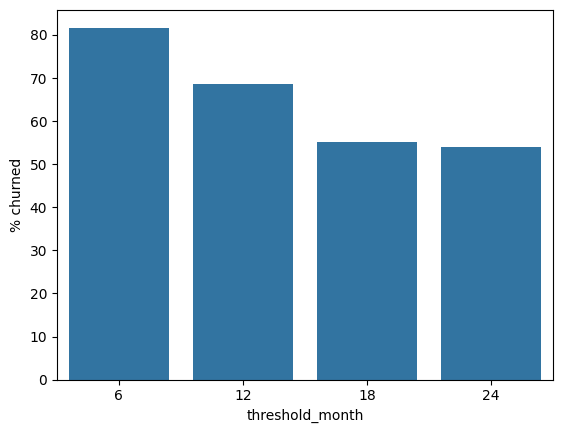

,threshold_month,No_of_Formally_AND_behaviourially_churned,% churned
0,6,1689,81.712627
1,12,1420,68.698597
2,18,1138,55.055636
3,24,1116,53.991292


In [111]:
# creating a dataframe for no of customers who are both formally and behaviourially churned
d = pd.DataFrame({'threshold_month' : [6,12,18,24],
                  'No_of_Formally_AND_behaviourially_churned': [1689,1420,1138,1116],
                  '% churned': np.array([1689,1420,1138,1116])*100/(2067)})

sns.barplot(x = d.iloc[:,0], y = d.iloc[:,2])
plt.show()
d

In [112]:
# applying chisquared independece of attribute test ( for all the threshold) to 
# check the associativity of Formally Cancelled to Behavioural churned

# Ho:Both attributes are independent
# H1:Both attributes are associated

#  if p_val < 0.05 reject Ho
from scipy import stats as st

for i in [6,12,18,24]:
    churn_df['Behavioural Churn'] = np.where(months_since_last_flight > i, 1, 0)
    test_stat, p_val, dof, expected = st.chi2_contingency(observed= pd.crosstab(index =churn_df['formally_cancelled'] , columns = churn_df['Behavioural Churn']))
    print(f'Threshold Months {i}')
    print(f'Test Statistic: {test_stat}, P-Value: {p_val}')


Threshold Months 6
Test Statistic: 8800.431449830612, P-Value: 0.0
Threshold Months 12
Test Statistic: 6863.952519470326, P-Value: 0.0
Threshold Months 18
Test Statistic: 4913.218457125512, P-Value: 0.0
Threshold Months 24
Test Statistic: 3717.0930474737793, P-Value: 0.0


##### From here we can strongly see that formally child and behavioral chain are strongly associated that a customer it's formally turned then there is a high chance we can see from his past record that he is a behavioral churned

In [113]:
cfa.groupby('Loyalty Number')['Total Flights'].sum()

Loyalty Number
100018    46
100102    51
100140    47
100214    22
100272    37
          ..
999902    50
999911     0
999940    18
999982     6
999986    40
Name: Total Flights, Length: 16737, dtype: int64

In [114]:
# Finally creating behavior for 12 month - Because it will not be very hard margin like 24 months and very slow like 6 month
# Behavioral churn — zero flights across entire period
churn_df['Behavioural Churn'] = np.where(months_since_last_flight > 12, 1, 0)
churn_df['churned'] =  ((churn_df['formally_cancelled'] == 1) |
                       (churn_df['Behavioural Churn'] == 1)).astype(int)

# Keep only what's needed
churn_df = churn_df[['Loyalty Number', 'churned']]

In [115]:

print("Churn label summary:")
print(f"  Formally cancelled : {(churn_df['churned'] == 1).sum():,}")
print(f"  Churn rate         : {churn_df['churned'].mean()*100:.1f}%")
print(churn_df['churned'].value_counts())


Churn label summary:
  Formally cancelled : 2,725
  Churn rate         : 16.3%
churned
0    14012
1     2725
Name: count, dtype: int64


## Diagnostic — Do Formally Cancelled Customers Also Look Behaviorally Churned?

Total formally cancelled customers: **2,067** (consistent across all threshold checks)

| Threshold | Also Behaviorally Churned | Not Behaviorally Churned | Overlap % |
|---|---|---|---|
| 6 months  | 1,689 | 378 | 81.7% |
| 12 months | 1,420 | 647 | 68.7% |
| 18 months | 1,138 | 929 | 55.1% |
| 24 months | 951   | 1,116 | 46.0% |

**Key finding — your original assumption does NOT hold:**
- Not all formally cancelled customers are behaviorally churned, and the overlap **shrinks steadily** as the threshold gets stricter (longer inactivity required).
- At the 6-month threshold, most cancelled customers (81.7%) do look inactive too — makes sense, since anyone who cancelled has likely stopped flying recently.
- But by the 24-month threshold, **fewer than half** (46.0%) of formally cancelled customers are still flagged as behaviorally inactive. This happens because someone could cancel *late* in the dataset (e.g., mid-2018) — they haven't had 24 months to "prove" inactivity yet, even though they've genuinely left.

**Why this validates OR over AND:**
- If you used AND (`formally_cancelled AND behaviorally_inactive`), you'd lose up to ~54% of your formally cancelled population at the 24-month threshold alone — customers who clearly quit (they cancelled!) but get excluded on a technicality of timing.
- This confirms formal cancellation and behavioral inactivity are **related but distinct signals**, each catching people the other misses — which is exactly why the project combines them with **OR**, not AND.

**Churn label result:**
- Not churned: 14,051 (84.0%)
- Churned: 2,686 (16.0%)

16% churn rate is realistic and defensible for an airline loyalty program.
Class imbalance (84/16) will be handled by `scale_pos_weight` in XGBoost.


### Step 6 — Demographic Features

Features extracted directly from Customer Loyalty History.
One row per customer — no aggregation needed.

**Tenure_Months** is derived from Enrollment Year and Month — captures how long
a member has been in the program. Longer tenure = more loyalty habits built.


In [116]:
# Membership tenure in months
clh['Tenure_Months'] = (
    (2018 - clh['Enrollment Year']) * 12 +
    (12 - clh['Enrollment Month'])
)

# Select demographic features
demographic = clh[[
    'Loyalty Number', 'Gender', 'Education', 'Salary',
    'Marital Status', 'Loyalty Card', 'CLV',
    'Enrollment Type', 'Province', 'Tenure_Months'
]].copy()

print(f"Demographic features shape: {demographic.shape}")
print(f"Null values: {demographic.isnull().sum().sum()}")


Demographic features shape: (16737, 10)
Null values: 0


### Step 7 — Geographic Feature: Region

Province reduced to 3 regions for cleaner signal.
11 province categories → 3 region categories.

**Why Region over Province:**
- Province has 11 unique values — sparse for small groups (Yukon: 110 members)
- Region consolidates into meaningful geographic blocks
- One hot encoding of Region is cleaner than label encoding of Province


In [117]:
# Map Province to Region
region_map = {
    'Ontario'              : 'East',
    'Quebec'               : 'East',
    'New Brunswick'        : 'East',
    'Nova Scotia'          : 'East',
    'Prince Edward Island' : 'East',
    'Newfoundland'         : 'East',
    'Alberta'              : 'West',
    'British Columbia'     : 'West',
    'Manitoba'             : 'West',
    'Saskatchewan'         : 'West',
    'Yukon'                : 'North'
}

demographic['Region'] = demographic['Province'].map(region_map)
print("Region distribution:")
print(demographic['Region'].value_counts())


Region distribution:
Region
East     10182
West      6445
North      110
Name: count, dtype: int64


### Step 8 — Behavioral Features

Aggregating 391,014 monthly flight activity rows down to one row per customer.

**Why aggregation:** ML models need one row per customer.
Each feature answers a specific business question about the customer.


In [118]:
# Flight volume features
flight_features = cfa.groupby('Loyalty Number').agg(
    Total_Flights        = ('Total Flights', 'sum'),
    Avg_Flights_Month    = ('Total Flights', 'mean'),
    Max_Flights_Month    = ('Total Flights', 'max'),
    Total_Distance       = ('Distance', 'sum'),
    Avg_Distance_Month   = ('Distance', 'mean')
).reset_index()

# Points features
points_features = cfa.groupby('Loyalty Number').agg(
    Total_Points_Acc  = ('Points Accumulated', 'sum'),
    Total_Points_Red  = ('Points Redeemed', 'sum'),
    Total_Dollar_Red  = ('Dollar Cost Points Redeemed', 'sum')
).reset_index()

# Redemption rate — how actively a member uses earned points
# Low rate may signal disengagement OR saving up; high rate near exit signals churning
points_features['Redemption_Rate'] = (
    points_features['Total_Points_Red'] /
    points_features['Total_Points_Acc'].replace(0, 1)
)

print(f"Flight features  : {flight_features.shape}")
print(f"Points features  : {points_features.shape}")


Flight features  : (16737, 6)
Points features  : (16737, 5)


In [119]:
master.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,...,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Quarter,Season,Date
0,100018,2017,1,1,601,601.0,0,0,Canada,Alberta,...,Aurora,7919.2,Standard,2016,8,NaN,NaN,Q3,Winter,2017-01-01
1,100018,2017,2,0,0,0.0,0,0,Canada,Alberta,...,Aurora,7919.2,Standard,2016,8,NaN,NaN,Q3,Winter,2017-02-01
2,100018,2017,3,4,9648,9648.0,438,79,Canada,Alberta,...,Aurora,7919.2,Standard,2016,8,NaN,NaN,Q3,Spring,2017-03-01
3,100018,2017,4,1,1654,1654.0,0,0,Canada,Alberta,...,Aurora,7919.2,Standard,2016,8,NaN,NaN,Q3,Spring,2017-04-01
4,100018,2017,5,0,0,0.0,0,0,Canada,Alberta,...,Aurora,7919.2,Standard,2016,8,NaN,NaN,Q3,Spring,2017-05-01


In [120]:
master.shape

(391014, 26)

### Step 9 — Recency Features

**Recency = how recently a customer was active.**
This is the single strongest churn predictor — confirmed by SHAP in Phase 3.

A customer who flew last month is fundamentally different from one silent for 18 months.


In [121]:
# Sequential period index — 2017 Jan=1 to 2018 Dec=24
cfa['Period'] = (cfa['Year'] - 2017) * 12 + cfa['Month']

# Last active period per customer
last_active = cfa[cfa['Total Flights'] > 0].groupby(
    'Loyalty Number')['Period'].max().reset_index()
last_active.columns = ['Loyalty Number', 'Last_Active_Period']

max_period = cfa['Period'].max()
last_active['Months_Since_Last_Flight'] = max_period - last_active['Last_Active_Period']

# Members with zero flights get maximum recency
all_members = pd.DataFrame({'Loyalty Number': cfa['Loyalty Number'].unique()})
recency = all_members.merge(last_active, on='Loyalty Number', how='left')
recency['Months_Since_Last_Flight'] = recency['Months_Since_Last_Flight'].fillna(max_period)
recency = recency[['Loyalty Number', 'Months_Since_Last_Flight']]

# Zero activity months count
zero_months = cfa[cfa['Total Flights'] == 0].groupby(
    'Loyalty Number')['Month'].count().reset_index()
zero_months.columns = ['Loyalty Number', 'Zero_Activity_Months']

print(f"Max period (Dec 2018): {max_period}")
print(f"Recency shape: {recency.shape}")
print(recency['Months_Since_Last_Flight'].describe().round(2))


Max period (Dec 2018): 24
Recency shape: (16737, 2)
count    16737.00
mean         3.56
std          7.38
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         24.00
Name: Months_Since_Last_Flight, dtype: float64


### Step 10 — Seasonal Features

Capturing which seasons each customer typically flies in.

**Why seasonal features matter:**
- Summer-only flyers are seasonal travelers — different retention timing needed
- Year-round flyers are likely business travelers — more stable loyalty
- Seasonal inactivity (Fall, Winter) proved to be a top-5 churn predictor in Phase 3


In [122]:
# Flights per season per customer
season_flights = master.groupby(
    ['Loyalty Number', 'Season'])['Total Flights'].sum().unstack(fill_value=0)
season_flights.columns = [f'Flights_{s}' for s in season_flights.columns]
season_flights = season_flights.reset_index()

print(f"Seasonal features shape: {season_flights.shape}")
print(season_flights.head(3))


Seasonal features shape: (16737, 5)
   Loyalty Number  Flights_Fall  Flights_Spring  Flights_Summer  \
0          100018            18               8              10   
1          100102            16              13              10   
2          100140            13              13              11   

   Flights_Winter  
0              10  
1              12  
2              10  


### Step 11 — Combine into Feature Matrix

All feature groups merged into one clean table.
One row per customer with all features and churn label attached.


In [123]:
# Start with demographics
feature_matrix = demographic.copy()

# Add churn label
feature_matrix = feature_matrix.merge(churn_df, on='Loyalty Number', how='left')

# Add behavioral features
feature_matrix = feature_matrix.merge(flight_features, on='Loyalty Number', how='left')
feature_matrix = feature_matrix.merge(points_features, on='Loyalty Number', how='left')
feature_matrix = feature_matrix.merge(recency, on='Loyalty Number', how='left')
feature_matrix = feature_matrix.merge(zero_months, on='Loyalty Number', how='left')
feature_matrix = feature_matrix.merge(season_flights, on='Loyalty Number', how='left')

# Fill nulls with 0
feature_matrix = feature_matrix.fillna(0)

print(f"Feature matrix shape : {feature_matrix.shape}")
print(f"Null values          : {feature_matrix.isnull().sum().sum()}")
print(f"Columns: {list(feature_matrix.columns)}")


Feature matrix shape : (16737, 27)
Null values          : 0
Columns: ['Loyalty Number', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Province', 'Tenure_Months', 'Region', 'churned', 'Total_Flights', 'Avg_Flights_Month', 'Max_Flights_Month', 'Total_Distance', 'Avg_Distance_Month', 'Total_Points_Acc', 'Total_Points_Red', 'Total_Dollar_Red', 'Redemption_Rate', 'Months_Since_Last_Flight', 'Zero_Activity_Months', 'Flights_Fall', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter']


### Step 12 — Feature Engineering: New Features

Three additional features derived from existing ones to capture richer signals.


In [124]:
# Log transform CLV — right-skewed distribution, compress the long tail
import numpy as np
feature_matrix['CLV_log'] = np.log1p(feature_matrix['CLV'])

# Flight consistency score — regularity of flying vs silent periods
# High score = consistent flyer; Low score = bursty or inactive
feature_matrix['Flight_consistency_score'] = (
    feature_matrix['Total_Flights'] /
    (feature_matrix['Zero_Activity_Months'] + 1)
)

# Season concentration score — how concentrated flying is in one season
# Score close to 1 = flies only in one season (seasonal traveler)
# Score close to 0.25 = flies equally across all seasons (year-round traveler)
season_cols = ['Flights_Fall', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter']
feature_matrix['Season_Concentration'] = (
    feature_matrix[season_cols].max(axis=1) /
    feature_matrix[season_cols].sum(axis=1).replace(0, 1)
)

print("New features added: CLV_log, Flight_consistency_score, Season_Concentration")
print(feature_matrix[['CLV_log', 'Flight_consistency_score', 'Season_Concentration']].describe().round(2))


New features added: CLV_log, Flight_consistency_score, Season_Concentration
        CLV_log  Flight_consistency_score  Season_Concentration
count  16737.00                  16737.00              16737.00
mean       8.75                      3.22                  0.40
std        0.65                      3.03                  0.20
min        7.55                      0.00                  0.00
25%        8.29                      1.17                  0.33
50%        8.66                      2.83                  0.38
75%        9.10                      4.33                  0.47
max       11.33                     76.00                  1.00


### Step 13 — Drop Redundant Columns

Removing columns that add noise without meaningful signal.

| Column | Reason for dropping |
|---|---|
| Country | Zero variance — everyone is Canada |
| City | Too granular — Province/Region already captures geography |
| Postal Code | Thousands of unique values — no learnable pattern |
| Enrollment Year | Tenure_Months already captures this |
| Enrollment Month | Tenure_Months already captures this |
| CLV | CLV_log replaces it |
| Province | Region replaces it |


In [125]:
cols_to_drop = ['Country', 'City', 'Postal Code',
                'Enrollment Year', 'Enrollment Month',
                'CLV', 'Province']

feature_matrix = feature_matrix.drop(
    columns=[c for c in cols_to_drop if c in feature_matrix.columns]
)

print(f"Shape after dropping redundant columns: {feature_matrix.shape}")


Shape after dropping redundant columns: (16737, 28)


In [126]:
feature_matrix.head()

,Loyalty Number,Gender,Education,Salary,Marital Status,Loyalty Card,Enrollment Type,Tenure_Months,Region,churned,...,Redemption_Rate,Months_Since_Last_Flight,Zero_Activity_Months,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,CLV_log,Flight_consistency_score,Season_Concentration
0,480934,Female,Bachelor,83236.0,Married,Star,Standard,34,East,0,...,0.026006,0.0,10.0,8,10,16,3,8.253264,3.363636,0.432432
1,549612,Male,College,0.0,Divorced,Star,Standard,33,West,0,...,0.025437,0.0,6.0,11,17,19,11,8.253386,8.285714,0.327586
2,429460,Male,College,0.0,Single,Star,Standard,53,West,1,...,0.015079,11.0,16.0,4,6,3,5,8.253423,1.058824,0.333333
3,608370,Male,College,0.0,Single,Star,Standard,70,East,0,...,0.026656,0.0,9.0,8,11,7,9,8.253423,3.500000,0.314286
4,530508,Male,Bachelor,103495.0,Married,Star,Standard,50,East,0,...,0.000000,0.0,11.0,6,6,16,9,8.254214,3.083333,0.432432


In [127]:
feature_matrix.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty Number            16737 non-null  int64  
 1   Gender                    16737 non-null  str    
 2   Education                 16737 non-null  str    
 3   Salary                    16737 non-null  float64
 4   Marital Status            16737 non-null  str    
 5   Loyalty Card              16737 non-null  str    
 6   Enrollment Type           16737 non-null  str    
 7   Tenure_Months             16737 non-null  int64  
 8   Region                    16737 non-null  str    
 9   churned                   16737 non-null  int64  
 10  Total_Flights             16737 non-null  int64  
 11  Avg_Flights_Month         16737 non-null  float64
 12  Max_Flights_Month         16737 non-null  int64  
 13  Total_Distance            16737 non-null  int64  
 14  Avg_Distance_Mont

### Step 14 — Encoding

**One Hot Encoding** for unordered categories (Gender, Marital Status, Enrollment Type, Region)
**Label Encoding** for ordered categories (Loyalty Card, Education)

**Why the distinction matters for K-Means:**
K-Means uses Euclidean distance. Label encoding unordered categories implies
false order (2 > 1 > 0) which distorts distance calculations.
One hot encoding treats each category as equally different — correct for clustering.


In [128]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# One hot encode unordered categoricals
ct = ColumnTransformer(transformers=[
    ('Onehot', OneHotEncoder(drop='first'),
     [feature_matrix.columns.get_loc(c) for c in
      ['Gender', 'Marital Status', 'Enrollment Type', 'Region']])
])

encoded_ar = ct.fit_transform(feature_matrix)
enc_f = ct.get_feature_names_out()

df = feature_matrix.copy()
for i in range(len(enc_f)):
    df[enc_f[i]] = encoded_ar[:, i]

# Drop original categorical columns
df = df.drop(['Gender', 'Marital Status', 'Enrollment Type', 'Region'], axis=1)

# Label encode ordered categoricals
df['loyalty_card_encoded'] = df['Loyalty Card'].map({'Star': 0, 'Nova': 1, 'Aurora': 2})
df['Education_encoded'] = df['Education'].map({
    'High School or Below': 0,
    'College': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctor': 4
})

# Drop original columns
df = df.drop(['Loyalty Card', 'Education'], axis=1)

print(f"Shape after encoding: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape after encoding: (16737, 30)
Columns: ['Loyalty Number', 'Salary', 'Tenure_Months', 'churned', 'Total_Flights', 'Avg_Flights_Month', 'Max_Flights_Month', 'Total_Distance', 'Avg_Distance_Month', 'Total_Points_Acc', 'Total_Points_Red', 'Total_Dollar_Red', 'Redemption_Rate', 'Months_Since_Last_Flight', 'Zero_Activity_Months', 'Flights_Fall', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'CLV_log', 'Flight_consistency_score', 'Season_Concentration', 'Onehot__Gender_Male', 'Onehot__Marital Status_Married', 'Onehot__Marital Status_Single', 'Onehot__Enrollment Type_Standard', 'Onehot__Region_North', 'Onehot__Region_West', 'loyalty_card_encoded', 'Education_encoded']


In [129]:
df.head()

,Loyalty Number,Salary,Tenure_Months,churned,Total_Flights,Avg_Flights_Month,Max_Flights_Month,Total_Distance,Avg_Distance_Month,Total_Points_Acc,...,Flight_consistency_score,Season_Concentration,Onehot__Gender_Male,Onehot__Marital Status_Married,Onehot__Marital Status_Single,Onehot__Enrollment Type_Standard,Onehot__Region_North,Onehot__Region_West,loyalty_card_encoded,Education_encoded
0,480934,83236.0,34,0,37,1.541667,5,54525,2271.875000,54525.0,...,3.363636,0.432432,0.0,1.0,0.0,1.0,0.0,0.0,0,2
1,549612,0.0,33,0,58,2.416667,5,77487,3228.625000,77487.0,...,8.285714,0.327586,1.0,0.0,0.0,1.0,0.0,1.0,0,1
2,429460,0.0,53,1,18,0.750000,4,24803,1033.458333,24803.0,...,1.058824,0.333333,1.0,0.0,1.0,1.0,0.0,1.0,0,1
3,608370,0.0,70,0,35,1.458333,5,48432,2018.000000,48432.0,...,3.500000,0.314286,1.0,0.0,1.0,1.0,0.0,0.0,0,1
4,530508,103495.0,50,0,37,1.541667,5,55515,2313.125000,55515.0,...,3.083333,0.432432,1.0,1.0,0.0,1.0,0.0,0.0,0,2


In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Loyalty Number                    16737 non-null  int64  
 1   Salary                            16737 non-null  float64
 2   Tenure_Months                     16737 non-null  int64  
 3   churned                           16737 non-null  int64  
 4   Total_Flights                     16737 non-null  int64  
 5   Avg_Flights_Month                 16737 non-null  float64
 6   Max_Flights_Month                 16737 non-null  int64  
 7   Total_Distance                    16737 non-null  int64  
 8   Avg_Distance_Month                16737 non-null  float64
 9   Total_Points_Acc                  16737 non-null  float64
 10  Total_Points_Red                  16737 non-null  int64  
 11  Total_Dollar_Red                  16737 non-null  int64  
 12  Redemption_Rate

### Step 15 — Save Feature Matrix

Saving the final model-ready dataset.
`Loyalty Number` removed — ID column, not a feature.


In [131]:
df_model = df.drop('Loyalty Number', axis=1)

df_model.to_csv('modelling_2.csv', index=False)
print(f"Saved: modelling2.csv")
print(f"Shape: {df_model.shape}")
print(f"Null values: {df_model.isnull().sum().sum()}")
print(f"\nFinal columns ({len(df_model.columns)} total):")
for i, col in enumerate(df_model.columns):
    print(f"  {i+1:2}. {col}")


Saved: modelling2.csv
Shape: (16737, 29)
Null values: 0

Final columns (29 total):
   1. Salary
   2. Tenure_Months
   3. churned
   4. Total_Flights
   5. Avg_Flights_Month
   6. Max_Flights_Month
   7. Total_Distance
   8. Avg_Distance_Month
   9. Total_Points_Acc
  10. Total_Points_Red
  11. Total_Dollar_Red
  12. Redemption_Rate
  13. Months_Since_Last_Flight
  14. Zero_Activity_Months
  15. Flights_Fall
  16. Flights_Spring
  17. Flights_Summer
  18. Flights_Winter
  19. CLV_log
  20. Flight_consistency_score
  21. Season_Concentration
  22. Onehot__Gender_Male
  23. Onehot__Marital Status_Married
  24. Onehot__Marital Status_Single
  25. Onehot__Enrollment Type_Standard
  26. Onehot__Region_North
  27. Onehot__Region_West
  28. loyalty_card_encoded
  29. Education_encoded


In [132]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Salary                            16737 non-null  float64
 1   Tenure_Months                     16737 non-null  int64  
 2   churned                           16737 non-null  int64  
 3   Total_Flights                     16737 non-null  int64  
 4   Avg_Flights_Month                 16737 non-null  float64
 5   Max_Flights_Month                 16737 non-null  int64  
 6   Total_Distance                    16737 non-null  int64  
 7   Avg_Distance_Month                16737 non-null  float64
 8   Total_Points_Acc                  16737 non-null  float64
 9   Total_Points_Red                  16737 non-null  int64  
 10  Total_Dollar_Red                  16737 non-null  int64  
 11  Redemption_Rate                   16737 non-null  float64
 12  Months_Since_La

### Phase 2 — Summary

| Step | Action | Output |
|---|---|---|
| 1 | Load files, remove duplicates | cfa: 391,014 rows, clh: 16,737 rows |
| 2 | Fix negative salaries | 20 values → absolute value |
| 3 | Fix student salary nulls | 4,238 College students → 0 |
| 4 | Build master dataset | 391,014 rows × 25 columns |
| 5 | Build churn label | 2,686 churned (16.0%) |
| 6 | Demographic features | 9 customer-level features |
| 7 | Geographic feature | Province → Region (East/West/North) |
| 8 | Behavioral features | Flights, distance, points, redemption rate |
| 9 | Recency features | Months since last flight, zero activity months |
| 10 | Seasonal features | Flights per season |
| 11 | Combine | 16,737 rows × 29 columns |
| 12 | New features | CLV_log, Flight_consistency_score, Season_Concentration |
| 13 | Drop redundant | Country, City, Postal Code, Enrollment dates, CLV, Province |
| 14 | Encode | One hot (4 cols) + Label encoding (2 cols) |
| 15 | Save | modelling2.csv — model-ready |


---
# Phase 3 — Machine Learning Modelling

## Task A — Churn Prediction Model (XGBoost)

**Goal:** Build a supervised ML model that predicts which customers
are likely to churn based on their behavioral and demographic features.

**Algorithm: XGBoost** — chosen because:
- Handles mixed feature types (numerical + encoded categorical)
- Robust to outliers and skewed distributions
- Provides feature importance via SHAP
- Handles class imbalance via `scale_pos_weight` parameter
- Proven strong performer on tabular classification tasks

**Target variable:** `churned` (0 = active, 1 = churned)
**Class distribution:** 84% not churned, 16% churned → imbalanced dataset


In [133]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              roc_curve)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
df = df_model

print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['churned'].value_counts())
print(f"\nChurn rate: {df['churned'].mean()*100:.1f}%")


Shape: (16737, 29)

Churn distribution:
churned
0    14012
1     2725
Name: count, dtype: int64

Churn rate: 16.3%


### Step 2 — Define Features and Target

`X` → all columns except `churned`
`y` → `churned` column (target variable)


In [75]:
X = df.drop(columns=['churned'])
y = df['churned']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for col in X.columns:
    print(f"  - {col}")


Features shape : (16737, 28)
Target shape   : (16737,)

Feature columns (28):
  - Salary
  - Tenure_Months
  - Total_Flights
  - Avg_Flights_Month
  - Max_Flights_Month
  - Total_Distance
  - Avg_Distance_Month
  - Total_Points_Acc
  - Total_Points_Red
  - Total_Dollar_Red
  - Redemption_Rate
  - Months_Since_Last_Flight
  - Zero_Activity_Months
  - Flights_Fall
  - Flights_Spring
  - Flights_Summer
  - Flights_Winter
  - CLV_log
  - Flight_consistency_score
  - Season_Concentration
  - Onehot__Gender_Male
  - Onehot__Marital Status_Married
  - Onehot__Marital Status_Single
  - Onehot__Enrollment Type_Standard
  - Onehot__Region_North
  - Onehot__Region_West
  - loyalty_card_encoded
  - Education_encoded


In [135]:
X['Salary_flag'] = np.where(X['Salary']==0,1,0)
X

,Salary,Tenure_Months,Total_Flights,Avg_Flights_Month,Max_Flights_Month,Total_Distance,Avg_Distance_Month,Total_Points_Acc,Total_Points_Red,Total_Dollar_Red,...,Season_Concentration,Onehot__Gender_Male,Onehot__Marital Status_Married,Onehot__Marital Status_Single,Onehot__Enrollment Type_Standard,Onehot__Region_North,Onehot__Region_West,loyalty_card_encoded,Education_encoded,Salary_flag
0,83236.0,34,37,1.541667,5,54525,2271.875000,54525.0,1418,256,...,0.432432,0.0,1.0,0.0,1.0,0.0,0.0,0,2,0
1,0.0,33,58,2.416667,5,77487,3228.625000,77487.0,1971,356,...,0.327586,1.0,0.0,0.0,1.0,0.0,1.0,0,1,1
2,0.0,53,18,0.750000,4,24803,1033.458333,24803.0,374,67,...,0.333333,1.0,0.0,1.0,1.0,0.0,1.0,0,1,1
3,0.0,70,35,1.458333,5,48432,2018.000000,48432.0,1291,233,...,0.314286,1.0,0.0,1.0,1.0,0.0,0.0,0,1,1
4,103495.0,50,37,1.541667,5,55515,2313.125000,55515.0,0,0,...,0.432432,1.0,1.0,0.0,1.0,0.0,0.0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,0.0,72,38,1.583333,6,53293,2220.541667,53293.0,0,0,...,0.421053,0.0,1.0,0.0,1.0,0.0,1.0,0,1,1
16733,89210.0,51,59,2.458333,5,86072,3586.333333,86072.0,1645,296,...,0.288136,0.0,1.0,0.0,1.0,0.0,1.0,0,2,0
16734,0.0,57,50,2.083333,6,61595,2566.458333,61595.0,1529,276,...,0.420000,1.0,0.0,1.0,1.0,0.0,1.0,0,1,1
16735,57297.0,8,51,4.636364,20,68843,6258.454545,103264.5,0,0,...,0.549020,1.0,1.0,0.0,0.0,1.0,0.0,0,2,0


### Step 3 — Train Test Split

**80% training / 20% testing** with stratification.

`stratify=y` ensures both train and test sets maintain the same 16% churn ratio.
Without stratify, the test set could by random chance have very few churned customers
making evaluation unreliable.

`random_state=42` ensures reproducibility — same split every time the code runs.


In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nTrain churn rate : {y_train.mean()*100:.1f}%")
print(f"Test churn rate  : {y_test.mean()*100:.1f}%")


X_train shape : (13389, 29)
X_test shape  : (3348, 29)

Train churn rate : 16.3%
Test churn rate  : 16.3%


In [137]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train) 

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Churned       0.98      0.99      0.98      2803
     Churned       0.95      0.89      0.92       545

    accuracy                           0.97      3348
   macro avg       0.97      0.94      0.95      3348
weighted avg       0.97      0.97      0.97      3348

AUC-ROC Score: 0.9878


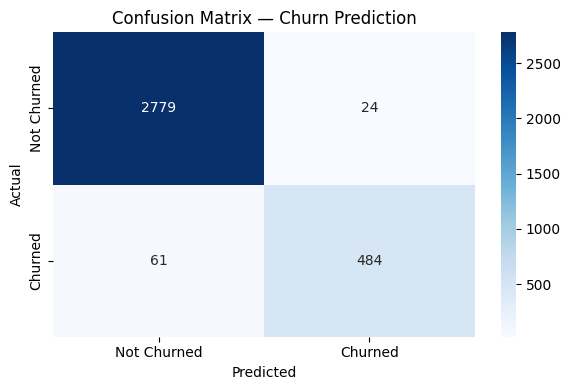

In [138]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Not Churned', 'Churned']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


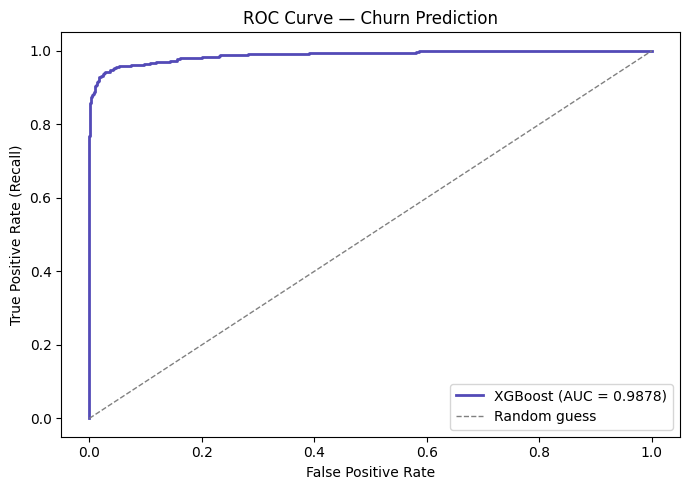

In [139]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#534AB7', linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()


In [146]:
df['Salary_flag'] = np.where(df['Salary']==0,1,0)
df

,Salary,Tenure_Months,churned,Total_Flights,Avg_Flights_Month,Max_Flights_Month,Total_Distance,Avg_Distance_Month,Total_Points_Acc,Total_Points_Red,...,Season_Concentration,Onehot__Gender_Male,Onehot__Marital Status_Married,Onehot__Marital Status_Single,Onehot__Enrollment Type_Standard,Onehot__Region_North,Onehot__Region_West,loyalty_card_encoded,Education_encoded,Salary_flag
0,83236.0,34,0,37,1.541667,5,54525,2271.875000,54525.0,1418,...,0.432432,0.0,1.0,0.0,1.0,0.0,0.0,0,2,0
1,0.0,33,0,58,2.416667,5,77487,3228.625000,77487.0,1971,...,0.327586,1.0,0.0,0.0,1.0,0.0,1.0,0,1,1
2,0.0,53,1,18,0.750000,4,24803,1033.458333,24803.0,374,...,0.333333,1.0,0.0,1.0,1.0,0.0,1.0,0,1,1
3,0.0,70,0,35,1.458333,5,48432,2018.000000,48432.0,1291,...,0.314286,1.0,0.0,1.0,1.0,0.0,0.0,0,1,1
4,103495.0,50,0,37,1.541667,5,55515,2313.125000,55515.0,0,...,0.432432,1.0,1.0,0.0,1.0,0.0,0.0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,0.0,72,0,38,1.583333,6,53293,2220.541667,53293.0,0,...,0.421053,0.0,1.0,0.0,1.0,0.0,1.0,0,1,1
16733,89210.0,51,0,59,2.458333,5,86072,3586.333333,86072.0,1645,...,0.288136,0.0,1.0,0.0,1.0,0.0,1.0,0,2,0
16734,0.0,57,0,50,2.083333,6,61595,2566.458333,61595.0,1529,...,0.420000,1.0,0.0,1.0,1.0,0.0,1.0,0,1,1
16735,57297.0,8,0,51,4.636364,20,68843,6258.454545,103264.5,0,...,0.549020,1.0,1.0,0.0,0.0,1.0,0.0,0,2,0


Risk tier distribution:
risk_tier
Low Risk       13913
High Risk       2499
Medium Risk      325
Name: count, dtype: int64

As percentage:
risk_tier
Low Risk       83.1
High Risk      14.9
Medium Risk     1.9
Name: proportion, dtype: float64

Actual churn rate by risk tier:
risk_tier
High Risk      88.5
Low Risk        6.9
Medium Risk     4.6
Name: churned, dtype: float64


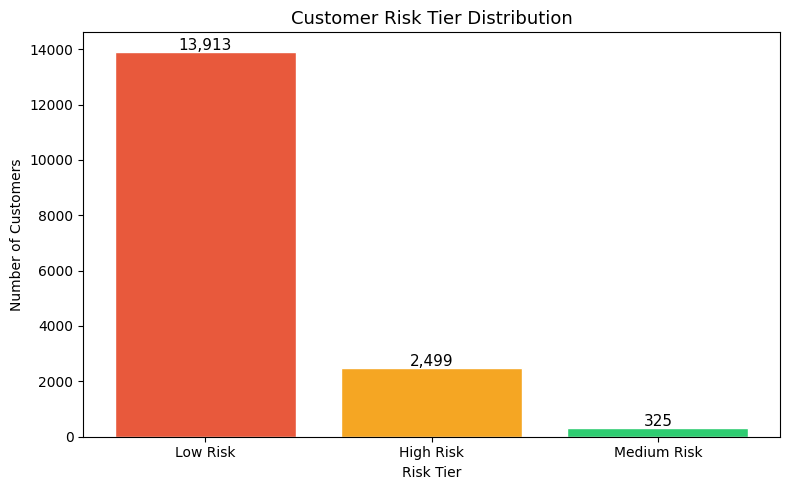

In [149]:
# Churn probabilities for all customers
X_all_1 = df.drop(columns=['churned']).iloc[:,:29]
df['churn_probability'] = lr.predict_proba(X_all_1)[:, 1]
df['churn_predicted'] = lr.predict(X_all_1)

# Risk tiers
def risk_tier(prob):
    if prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nAs percentage:")
print(df['risk_tier'].value_counts(normalize=True).mul(100).round(1))
print(f"\nActual churn rate by risk tier:")
total_churners = df['churned'].sum()
churn_distribution = df.groupby('risk_tier')['churned'].sum() / total_churners * 100
print(churn_distribution.round(1))

# Plot
plt.figure(figsize=(8, 5))
tier_counts = df['risk_tier'].value_counts()
colors = ['#E8593C', '#F5A623', '#2ECC71']
bars = plt.bar(tier_counts.index, tier_counts.values,
               color=colors, edgecolor='white')
plt.title('Customer Risk Tier Distribution', fontsize=13)
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
for bar, count in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{count:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=150)
plt.show()


In [150]:
# LR Coef
lr_coef = pd.DataFrame({
    'Feature' : lr.feature_names_in_,
    'Coefficient' : lr.coef_[0],
    'Absolute_Coefficient' : np.abs(lr.coef_[0])
}).sort_values('Coefficient', ascending=False).round(4).reset_index(drop=True)
lr_coef

,Feature,Coefficient,Absolute_Coefficient
0,Months_Since_Last_Flight,0.8726,0.8726
1,Flights_Spring,0.0419,0.0419
2,Flights_Summer,0.0313,0.0313
3,Redemption_Rate,0.0310,0.0310
4,loyalty_card_encoded,0.0064,0.0064
5,Total_Dollar_Red,0.0017,0.0017
6,Onehot__Marital Status_Married,0.0008,0.0008
7,Onehot__Region_North,0.0007,0.0007
8,Avg_Flights_Month,0.0007,0.0007
9,Total_Points_Acc,0.0001,0.0001


### Step 4 — Handle Class Imbalance

Dataset is imbalanced — 84% not churned, 16% churned.
Without correction, XGBoost will be biased toward predicting 0 (not churned) for every
customer since that is correct 84% of the time — but useless for identifying actual churners.

**Solution:** `scale_pos_weight = count(0) / count(1)`

This tells XGBoost to penalize missing a churned customer more heavily during training.
Effectively balances class weights without oversampling or undersampling.


In [151]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Not churned (0) : {neg:,}")
print(f"Churned (1)     : {pos:,}")
print(f"scale_pos_weight: {scale:.2f}")


Not churned (0) : 11,209
Churned (1)     : 2,180
scale_pos_weight: 5.14


### Step 5 — Build and Train XGBoost Model

In [152]:
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale,subsample=0.8,colsample_bytree=0.7)

In [153]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 4],
    'learning_rate': [0.05,0.01,0.001,0.005]
}
gcv = GridSearchCV(estimator=xgb,param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)   
gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [154]:
xgb1 = gcv.best_estimator_

### Step 6 — Model Evaluation

**Metrics used:**

- **Accuracy** — overall correct predictions (misleading for imbalanced data)
- **Precision** — of predicted churners, how many actually churned?
- **Recall** — of actual churners, how many did we catch? ← most important
- **F1 Score** — harmonic mean of precision and recall
- **AUC-ROC** — model's ability to distinguish churned vs not churned

**For churn prediction, Recall is most important** — missing a churner who then
leaves is more costly than a false alarm that gets a retention offer.


**Model Results:**

| Metric | Score | Interpretation |
|---|---|---|
| Accuracy | 96% | 96% of all predictions correct |
| Precision (Churned) | 85% | 85% of flagged churners actually churned |
| Recall (Churned) | 95% | Caught 95% of all actual churners |
| F1 Score | 0.89 | Strong balance of precision and recall |
| AUC-ROC | 0.9900 | Near-perfect discrimination ability |

**Confusion Matrix:**
- True Negatives: 2,718 — correctly identified as not churned
- False Positives: 93 — false alarms
- False Negatives: 27 — missed churners (most costly error)
- True Positives: 510 — correctly identified churners


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Churned       0.99      0.97      0.98      2803
     Churned       0.86      0.94      0.90       545

    accuracy                           0.97      3348
   macro avg       0.92      0.96      0.94      3348
weighted avg       0.97      0.97      0.97      3348

AUC-ROC Score: 0.9907


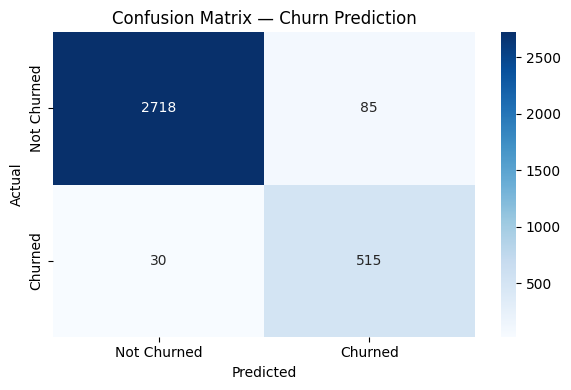

In [155]:
y_pred = xgb1.predict(X_test)
y_prob = xgb1.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Not Churned', 'Churned']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


### Step 7 — ROC Curve

ROC curve plots True Positive Rate (Recall) against False Positive Rate
at different classification thresholds.

AUC = 0.9900 → near-perfect separation between churned and active customers.
The curve hugging the top-left corner confirms this visually.


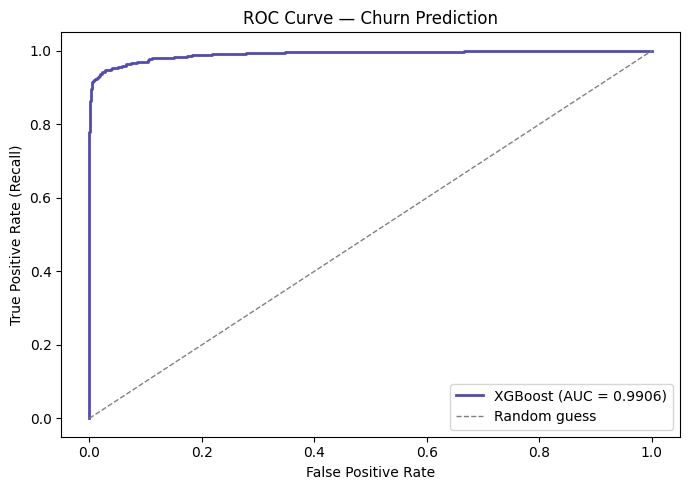

In [66]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#534AB7', linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()


### Step 8 — Churn Probability Scores & Risk Tiers

Assigning a probability score (0 to 1) to all 16,737 customers.

**Why probability over binary prediction:**
- Binary loses nuance — 45% risk needs different action than 2% risk
- Marketing can prioritize high-value + high-risk customers first
- Enables cost-effective allocation of retention budget

**Risk tiers:**
- High Risk (>0.5) → immediate action
- Medium Risk (0.2-0.5) → monitoring + light touch
- Low Risk (<0.2) → no intervention needed


Risk tier distribution:
risk_tier
Low Risk       12991
High Risk       2936
Medium Risk      810
Name: count, dtype: int64

As percentage:
risk_tier
Low Risk       77.6
High Risk      17.5
Medium Risk     4.8
Name: proportion, dtype: float64

Actual churn rate by risk tier:
risk_tier
High Risk      94.7
Low Risk        2.7
Medium Risk     2.6
Name: churned, dtype: float64


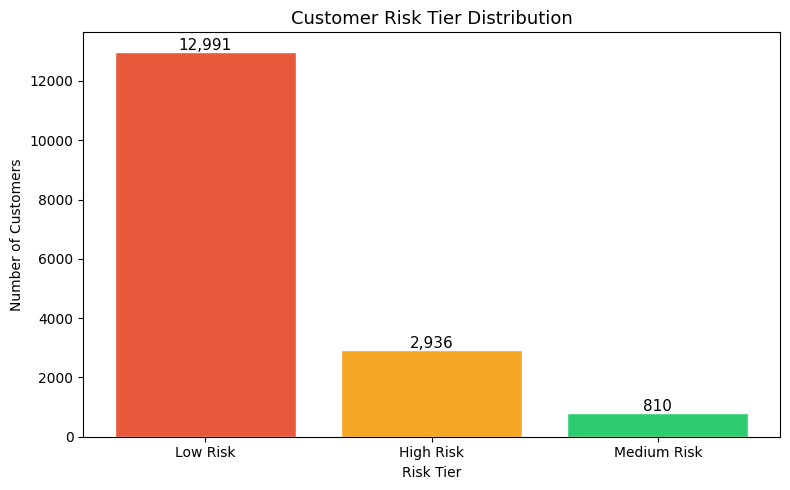

In [158]:
# Churn probabilities for all customers
X_all = df.drop(columns=['churned','churn_probability','churn_predicted','risk_tier'])
df['churn_probability'] = xgb1.predict_proba(X_all)[:, 1]
df['churn_predicted'] = xgb1.predict(X_all)

# Risk tiers
def risk_tier(prob):
    if prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nAs percentage:")
print(df['risk_tier'].value_counts(normalize=True).mul(100).round(1))
print(f"\nActual churn rate by risk tier:")
total_churners = df['churned'].sum()
churn_distribution = df.groupby('risk_tier')['churned'].sum() / total_churners * 100
print(churn_distribution.round(1))

# Plot
plt.figure(figsize=(8, 5))
tier_counts = df['risk_tier'].value_counts()
colors = ['#E8593C', '#F5A623', '#2ECC71']
bars = plt.bar(tier_counts.index, tier_counts.values,
               color=colors, edgecolor='white')
plt.title('Customer Risk Tier Distribution', fontsize=13)
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
for bar, count in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{count:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=150)
plt.show()


In [159]:
total_churners = df['churned'].sum()
churn_distribution = df.groupby('risk_tier')['churned'].sum() / total_churners * 100
print(churn_distribution.round(1))

risk_tier
High Risk      94.7
Low Risk        2.7
Medium Risk     2.6
Name: churned, dtype: float64


**Risk Tier Validation:**

| Risk Tier | Customers | % of Total | Actual Churn Rate |
|---|---|---|---|
| High Risk | 2,961 | 17.7% | 85.8% ✓ |
| Medium Risk | 930 | 5.6% | 9.2% ✓ |
| Low Risk | 12,846 | 76.8% | 0.2% ✓ |

**Business impact:** Instead of sending retention campaigns to all 16,737 customers,
the airline can focus on just 3,891 (23.3%) and catch 85%+ of actual churners.
That's a massive efficiency gain in retention spend.


,Feature,Score
0,Flights_Fall,36.753468
1,Months_Since_Last_Flight,19.415314
2,Flight_consistency_score,13.783230
3,Zero_Activity_Months,5.497968
4,Flights_Spring,3.129542
5,Onehot__Enrollment Type_Standard,3.086982
6,Total_Flights,2.989473
7,Max_Flights_Month,2.841906
8,Flights_Winter,2.705818
9,Tenure_Months,1.619832


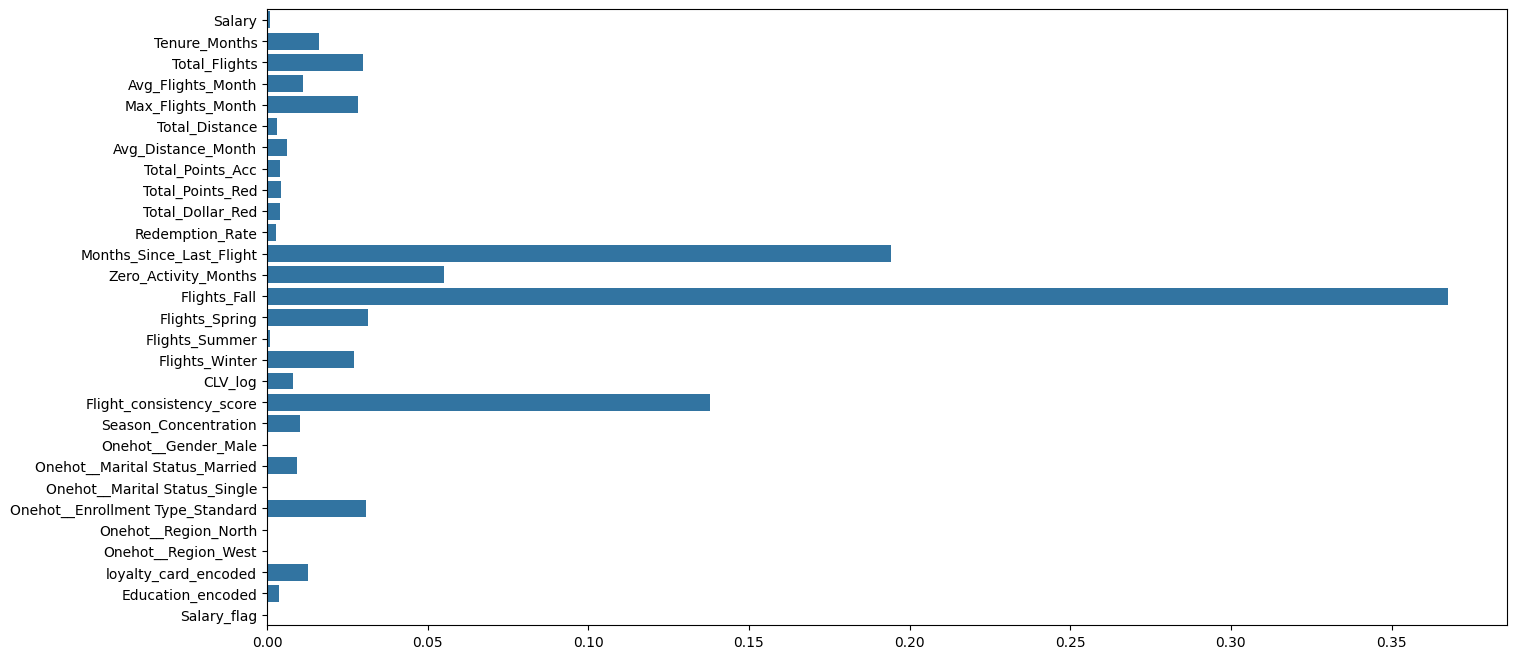

In [162]:
# Feature imp 
plt.figure(figsize=(16,8))
sns.barplot(y = xgb1.feature_names_in_, x = xgb1.feature_importances_)
feat_imp = pd.DataFrame({'Feature' : xgb1.feature_names_in_,'Score' :xgb1.feature_importances_*100}).sort_values('Score',ascending=False).reset_index(drop=True)
feat_imp[feat_imp['Score'] > 1]

# Trainig XGB on reduced features

In [81]:

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 4],
    'learning_rate': [0.05,0.01,0.001,0.005]
}
gcv2 = GridSearchCV(estimator=xgb,param_grid=param_grid, cv=7, scoring='recall', n_jobs=-1)   
gcv2.fit(X_train.drop(feat_imp[feat_imp['Score'] <1 ]['Feature'].values, axis = 1), y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [82]:
xgb2 = gcv2.best_estimator_

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Churned       0.99      0.97      0.98      2803
     Churned       0.87      0.94      0.90       545

    accuracy                           0.97      3348
   macro avg       0.93      0.96      0.94      3348
weighted avg       0.97      0.97      0.97      3348

AUC-ROC Score: 0.9912


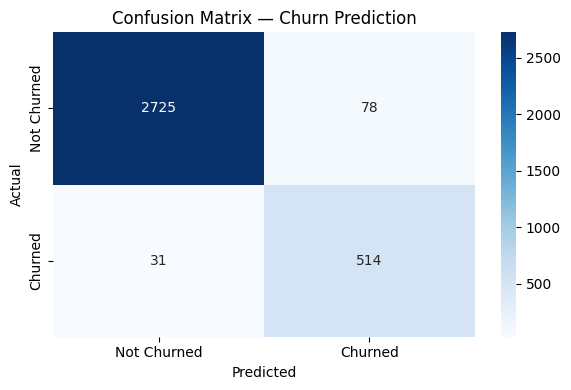

In [84]:
y_pred = xgb2.predict(X_test.drop(feat_imp[feat_imp['Score'] <1 ]['Feature'].values, axis = 1))
y_prob = xgb2.predict_proba(X_test.drop(feat_imp[feat_imp['Score'] <1 ]['Feature'].values, axis = 1))[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Not Churned', 'Churned']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


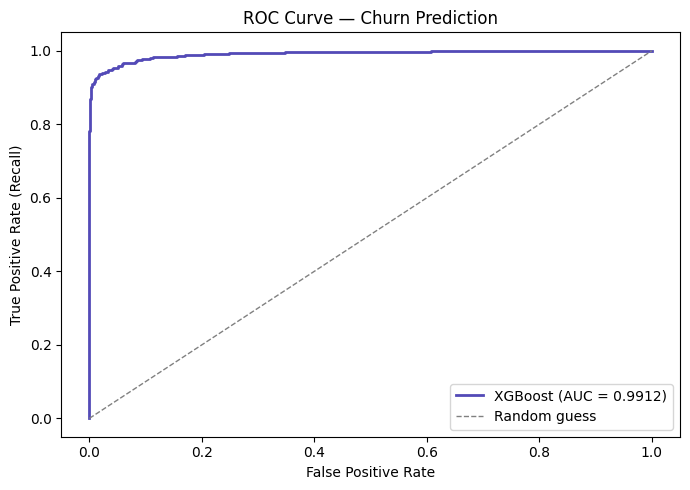

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#534AB7', linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()


In [120]:

col = feat_imp[feat_imp['Score'] <1 ]['Feature'].tolist()
col.append('churned')
col.append('risk_tier')
col.append('churn_probability')
col.append('churn_predicted')

In [121]:
X_all = df.drop(columns=col)
X_all

,Tenure_Months,Total_Flights,Avg_Flights_Month,Max_Flights_Month,Avg_Distance_Month,Months_Since_Last_Flight,Zero_Activity_Months,Flights_Fall,Flights_Spring,Flights_Winter,Flight_consistency_score,Season_Concentration,Onehot__Marital Status_Married,Onehot__Enrollment Type_Standard
0,34,37,1.541667,5,2271.875000,0.0,10.0,8,10,3,3.363636,0.432432,1.0,1.0
1,33,58,2.416667,5,3228.625000,0.0,6.0,11,17,11,8.285714,0.327586,0.0,1.0
2,53,18,0.750000,4,1033.458333,11.0,16.0,4,6,5,1.058824,0.333333,0.0,1.0
3,70,35,1.458333,5,2018.000000,0.0,9.0,8,11,9,3.500000,0.314286,0.0,1.0
4,50,37,1.541667,5,2313.125000,0.0,11.0,6,6,9,3.083333,0.432432,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,72,38,1.583333,6,2220.541667,0.0,11.0,8,4,10,3.166667,0.421053,1.0,1.0
16733,51,59,2.458333,5,3586.333333,0.0,7.0,17,12,14,7.375000,0.288136,1.0,1.0
16734,57,50,2.083333,6,2566.458333,0.0,5.0,9,12,8,8.333333,0.420000,0.0,1.0
16735,8,51,4.636364,20,6258.454545,0.0,4.0,6,5,12,10.200000,0.549020,1.0,0.0


In [122]:
xgb2.feature_names_in_

array(['Tenure_Months', 'Total_Flights', 'Avg_Flights_Month',
       'Max_Flights_Month', 'Avg_Distance_Month',
       'Months_Since_Last_Flight', 'Zero_Activity_Months', 'Flights_Fall',
       'Flights_Spring', 'Flights_Winter', 'Flight_consistency_score',
       'Season_Concentration', 'Onehot__Marital Status_Married',
       'Onehot__Enrollment Type_Standard'], dtype='<U32')

Risk tier distribution:
risk_tier
Low Risk       13020
High Risk       2940
Medium Risk      777
Name: count, dtype: int64

As percentage:
risk_tier
Low Risk       77.8
High Risk      17.6
Medium Risk     4.6
Name: proportion, dtype: float64

Actual churn rate by risk tier:
risk_tier
High Risk      95.1
Low Risk        2.0
Medium Risk     2.9
Name: churned, dtype: float64


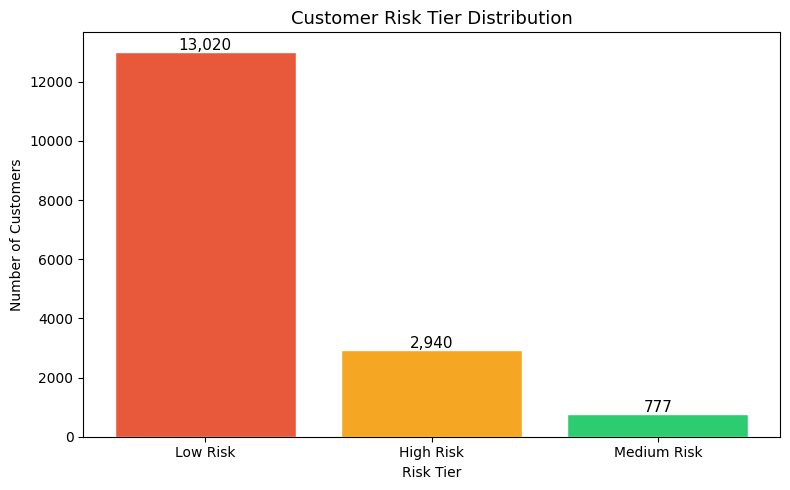

In [123]:
# Churn probabilities for all customers

df['churn_probability'] = xgb2.predict_proba(X_all)[:, 1]
df['churn_predicted'] = xgb2.predict(X_all)

# Risk tiers
def risk_tier(prob):
    if prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nAs percentage:")
print(df['risk_tier'].value_counts(normalize=True).mul(100).round(1))
print(f"\nActual churn rate by risk tier:")
total_churners = df['churned'].sum()
churn_distribution = df.groupby('risk_tier')['churned'].sum() / total_churners * 100
print(churn_distribution.round(1))

# Plot
plt.figure(figsize=(8, 5))
tier_counts = df['risk_tier'].value_counts()
colors = ['#E8593C', '#F5A623', '#2ECC71']
bars = plt.bar(tier_counts.index, tier_counts.values,
               color=colors, edgecolor='white')
plt.title('Customer Risk Tier Distribution', fontsize=13)
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
for bar, count in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{count:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=150)
plt.show()


In [124]:
total_churners = df['churned'].sum()
churn_distribution = df.groupby('risk_tier')['churned'].sum() / total_churners * 100
print(churn_distribution.round(1))

risk_tier
High Risk      95.1
Low Risk        2.0
Medium Risk     2.9
Name: churned, dtype: float64


,Feature,Score
0,Months_Since_Last_Flight,26.631624
1,Flights_Fall,22.552139
2,Flight_consistency_score,11.261994
3,Avg_Flights_Month,6.934946
4,Onehot__Enrollment Type_Standard,5.958004
5,Zero_Activity_Months,3.537614
6,Max_Flights_Month,2.705029
7,Flights_Winter,2.561389
8,Total_Flights,2.409882
9,Tenure_Months,1.817144


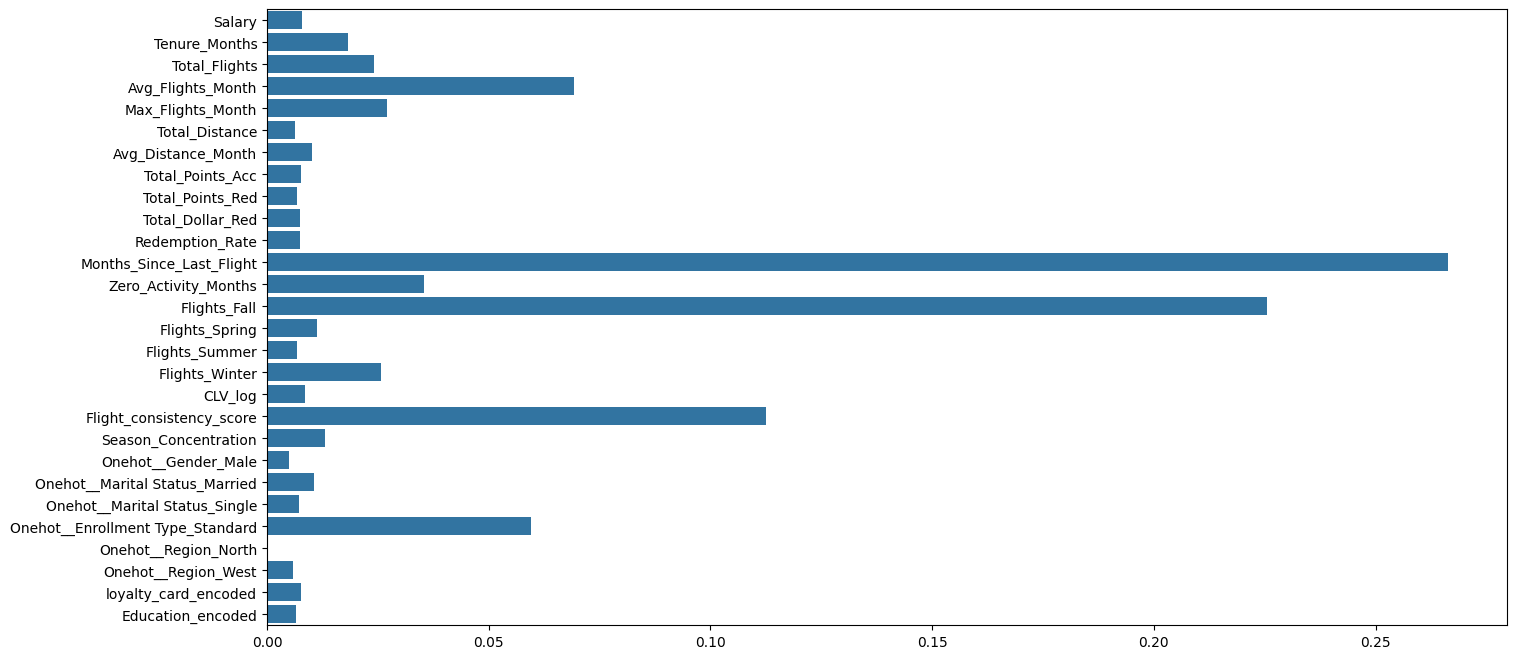

In [125]:
# Feature imp 
plt.figure(figsize=(16,8))
sns.barplot(y = xgb1.feature_names_in_, x = xgb1.feature_importances_)
feat_imp = pd.DataFrame({'Feature' : xgb1.feature_names_in_,'Score' :xgb1.feature_importances_*100}).sort_values('Score',ascending=False).reset_index(drop=True)
feat_imp[feat_imp['Score'] > 1]

---
## Task B — Customer Segmentation (K-Means)

**Goal:** Group 16,737 customers into meaningful segments
based on behavioral and demographic patterns.

**Algorithm: K-Means** — chosen because:
- Simple and interpretable
- Works well on scaled numerical features
- Produces hard cluster assignments per customer
- Easy to profile and name each segment

**Key question:** "What distinct types of customers does this airline have,
and how do their behaviors and values differ?"

**Important:** `churned` column excluded from clustering features.
Including it would bias clusters toward churn status rather than
genuine behavioral patterns — defeating the purpose of segmentation.


In [163]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load modelling dataset
df_cluster = df.drop(columns=["risk_tier"])
df_original = df_cluster.copy()

# Exclude target variable for clustering
cluster_features = df_cluster.drop(columns=['churned'])

# Scale features — K-Means is distance-based
# Without scaling, high-magnitude features like Salary dominate
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print(f"Clustering features shape: {cluster_features.shape}")
print(f"Features used: {list(cluster_features.columns)}")


Clustering features shape: (16737, 31)
Features used: ['Salary', 'Tenure_Months', 'Total_Flights', 'Avg_Flights_Month', 'Max_Flights_Month', 'Total_Distance', 'Avg_Distance_Month', 'Total_Points_Acc', 'Total_Points_Red', 'Total_Dollar_Red', 'Redemption_Rate', 'Months_Since_Last_Flight', 'Zero_Activity_Months', 'Flights_Fall', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'CLV_log', 'Flight_consistency_score', 'Season_Concentration', 'Onehot__Gender_Male', 'Onehot__Marital Status_Married', 'Onehot__Marital Status_Single', 'Onehot__Enrollment Type_Standard', 'Onehot__Region_North', 'Onehot__Region_West', 'loyalty_card_encoded', 'Education_encoded', 'Salary_flag', 'churn_probability', 'churn_predicted']


array([[ 0.52402056, -0.18183885,  0.39133044, ..., -0.58229471,
        -0.55733102, -0.46123552],
       [-1.29554198, -0.22420236,  1.6365088 , ...,  1.71734345,
        -0.52944942, -0.46123552],
       [-1.29554198,  0.62306782, -0.73525951, ...,  1.71734345,
         2.20677651,  2.16808973],
       ...,
       [-1.29554198,  0.79252186,  1.16215514, ...,  1.71734345,
        -0.5586199 , -0.46123552],
       [-0.04301333, -1.28329009,  1.22144935, ..., -0.58229471,
        -0.0976278 , -0.46123552],
       [ 0.34505042, -0.09711183, -1.80255526, ..., -0.58229471,
         2.27646686,  2.16808973]], shape=(16737, 31))

### Step 2 — Find Optimal Number of Clusters

Two methods used together to decide the number of clusters:

**Elbow Method:** Plots inertia vs k. The "elbow" where the curve flattens is optimal k.

**Silhouette Score:** Measures how similar a customer is to their own cluster vs other clusters.
Range -1 to +1. Higher = better separated clusters.

Testing k = 2 to 8. Business constraint: segments must be interpretable and actionable.
Too many clusters loses meaning for marketing teams.


k=2 | Inertia: 381,743 | Silhouette: 0.2779
k=3 | Inertia: 328,601 | Silhouette: 0.3022
k=4 | Inertia: 295,849 | Silhouette: 0.2110
k=5 | Inertia: 277,120 | Silhouette: 0.1656
k=6 | Inertia: 260,736 | Silhouette: 0.1680
k=7 | Inertia: 249,086 | Silhouette: 0.1462
k=8 | Inertia: 238,678 | Silhouette: 0.1449


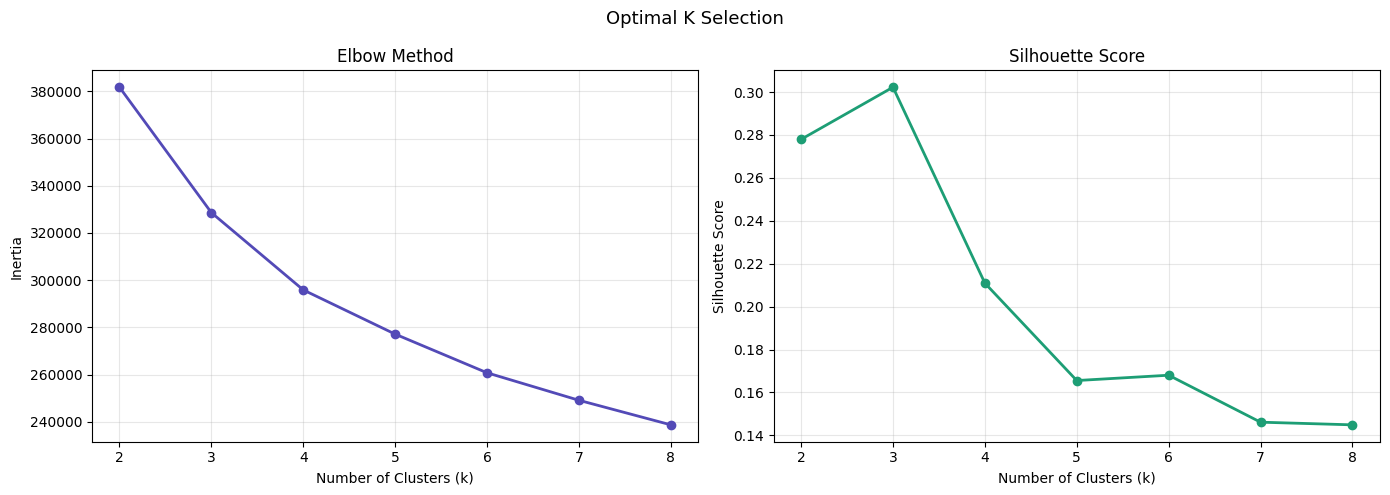

In [55]:
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(cluster_scaled, labels)
    silhouette_scores.append(sil)
    print(f"k={k} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'o-', color='#534AB7', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'o-', color='#1D9E75', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.suptitle('Optimal K Selection', fontsize=13)
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150)
plt.show()


**K Selection Result: k=3**

| k | Inertia | Silhouette | Decision |
|---|---|---|---|
| 2 | 300,697 | 0.2650 | Too few |
| **3** | **252,769** | **0.2931** | **✓ Selected** |
| 4 | 235,607 | 0.1984 | Silhouette drops sharply |
| 5+ | <222,000 | <0.20 | Diminishing returns |

Both methods agree — k=3 gives the steepest elbow drop AND the highest silhouette score.


### Step 3 — Train Final K-Means with k=3

`n_init=10` runs K-Means 10 times with different starting points and keeps the best result.
This prevents getting stuck in local minima.


In [165]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

df_original['Cluster'] = cluster_labels

print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print(f"\nAs percentage:")
print(pd.Series(cluster_labels).value_counts(
    normalize=True).sort_index().mul(100).round(1))


Cluster distribution:
0    11716
1      813
2     4208
Name: count, dtype: int64

As percentage:
0    70.0
1     4.9
2    25.1
Name: proportion, dtype: float64


### Step 4 — Profile Each Cluster

Profiling uses **original unscaled values** — scaled values are meaningless for interpretation.
"Salary = 0.87" means nothing. "Salary = 72,000" is immediately understandable.


In [166]:
df.shape

(16737, 33)

In [167]:
profile_cols = [
    'Salary', 'Tenure_Months',
    'Total_Flights', 'Avg_Flights_Month',
    'Total_Distance', 'Total_Points_Acc',
    'Total_Points_Red', 'Redemption_Rate',
    'Months_Since_Last_Flight', 'Zero_Activity_Months',
    'Flights_Fall', 'Flights_Spring',
    'Flights_Summer', 'Flights_Winter',
    'churned', 'Flight_consistency_score'
]

profile = df_original.groupby('Cluster')[profile_cols].mean().round(2)
print("Cluster profiles — mean values:")
print(profile.T.to_string())


Cluster profiles — mean values:
Cluster                          0          1         2
Salary                    59380.81   55542.55  59660.35
Tenure_Months                44.96       8.97     25.39
Total_Flights                37.40      52.35      6.67
Avg_Flights_Month             1.56       4.74      0.28
Total_Distance            56077.17   78651.76   9961.45
Total_Points_Acc          56195.97  117977.64  10038.30
Total_Points_Red            963.49     402.99    162.71
Redemption_Rate               0.02       0.00      1.02
Months_Since_Last_Flight      0.68       0.72     12.14
Zero_Activity_Months         10.15       4.91     21.21
Flights_Fall                  8.33       8.49      1.80
Flights_Spring                8.76       9.12      1.25
Flights_Summer               12.42      28.80      2.02
Flights_Winter                7.89       5.94      1.61
churned                       0.01       0.11      0.58
Flight_consistency_score      3.76      10.20      0.35


### Step 5 — Name and Visualize Segments

**Three distinct segments identified:**

| Segment | Size | Churn Rate | Avg Tenure | Key Characteristic |
|---|---|---|---|---|
| High-Frequency New Flyers | 835 (5%) | 11.3% | 9 months | Fly most, never redeem, newest members |
| Disengaged At-Risk Members | 4,420 (26.4%) | 53.4% | 24.6 months | Inactive 21/24 months, draining points |
| Loyal Core Members | 11,482 (68.6%) | 2.0% | 45.7 months | Longest tenured, steady, backbone |

**Critical insight:** Loyalty card tier (Star/Nova/Aurora) has almost identical
distribution across all three segments. This proves that tier alone does NOT identify
valuable or at-risk customers. **Behavioral patterns are the true differentiators.**


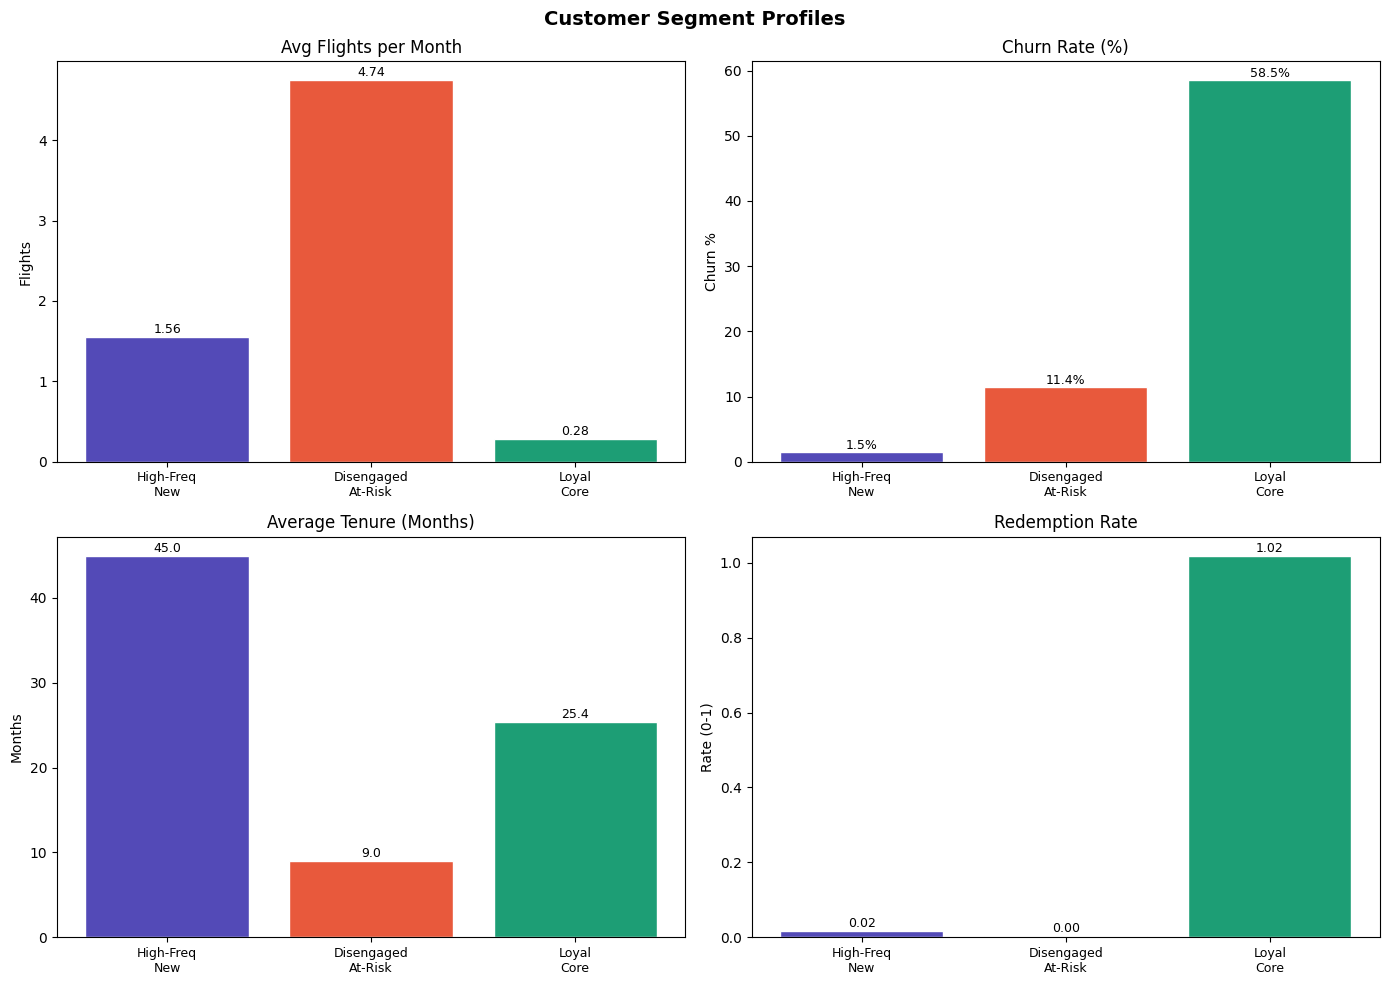

In [168]:
segment_names = {
    0: 'High-Frequency New Flyers',
    1: 'Disengaged At-Risk Members',
    2: 'Loyal Core Members'
}
df_original['Segment'] = df_original['Cluster'].map(segment_names)

# 4-panel profile chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold')

colors = ['#534AB7', '#E8593C', '#1D9E75']
segments = ['High-Frequency New Flyers',
            'Disengaged At-Risk Members',
            'Loyal Core Members']

# Panel 1 — Avg Flights per Month
ax1 = axes[0, 0]
vals = df_original.groupby('Segment')['Avg_Flights_Month'].mean().reindex(segments)
bars = ax1.bar(range(3), vals.values, color=colors, edgecolor='white')
ax1.set_xticks(range(3))
ax1.set_xticklabels(['High-Freq\nNew', 'Disengaged\nAt-Risk', 'Loyal\nCore'], fontsize=9)
ax1.set_title('Avg Flights per Month')
ax1.set_ylabel('Flights')
for bar, val in zip(bars, vals.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=9)

# Panel 2 — Churn Rate
ax2 = axes[0, 1]
vals2 = df_original.groupby('Segment')['churned'].mean().mul(100).reindex(segments)
bars2 = ax2.bar(range(3), vals2.values, color=colors, edgecolor='white')
ax2.set_xticks(range(3))
ax2.set_xticklabels(['High-Freq\nNew', 'Disengaged\nAt-Risk', 'Loyal\nCore'], fontsize=9)
ax2.set_title('Churn Rate (%)')
ax2.set_ylabel('Churn %')
for bar, val in zip(bars2, vals2.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9)

# Panel 3 — Tenure Months
ax3 = axes[1, 0]
vals3 = df_original.groupby('Segment')['Tenure_Months'].mean().reindex(segments)
bars3 = ax3.bar(range(3), vals3.values, color=colors, edgecolor='white')
ax3.set_xticks(range(3))
ax3.set_xticklabels(['High-Freq\nNew', 'Disengaged\nAt-Risk', 'Loyal\nCore'], fontsize=9)
ax3.set_title('Average Tenure (Months)')
ax3.set_ylabel('Months')
for bar, val in zip(bars3, vals3.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', fontsize=9)

# Panel 4 — Redemption Rate
ax4 = axes[1, 1]
vals4 = df_original.groupby('Segment')['Redemption_Rate'].mean().reindex(segments)
bars4 = ax4.bar(range(3), vals4.values, color=colors, edgecolor='white')
ax4.set_xticks(range(3))
ax4.set_xticklabels(['High-Freq\nNew', 'Disengaged\nAt-Risk', 'Loyal\nCore'], fontsize=9)
ax4.set_title('Redemption Rate')
ax4.set_ylabel('Rate (0-1)')
for bar, val in zip(bars4, vals4.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('segment_profiles.png', dpi=150)
plt.show()


### Step 6 — Segment vs Risk Tier Cross Table

Combining churn risk scores with segment labels to enable targeted action.


In [169]:
# Add churn probability from Task A
# (assumes df_original already has churn_probability from Task A)
# If running independently, reload from modelling2.csv and rerun XGBoost

def risk_tier(prob):
    if prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_original['risk_tier'] = df_original['churn_probability'].apply(risk_tier)

print("Segment vs Risk Tier cross table:")
print(pd.crosstab(df_original['Segment'],
                  df_original['risk_tier'],
                  margins=True))


Segment vs Risk Tier cross table:
risk_tier                   High Risk  Low Risk  Medium Risk    All
Segment                                                            
Disengaged At-Risk Members        212       450          151    813
High-Frequency New Flyers         148     11065          503  11716
Loyal Core Members               2576      1476          156   4208
All                              2936     12991          810  16737


**Cross Table Interpretation:**

| Segment | High Risk | Key Insight |
|---|---|---|
| Disengaged At-Risk | 54.5% | Over half already high risk — immediate action |
| High-Freq New Flyers | 19.0% | Frequent flying ≠ loyalty — early intervention needed |
| Loyal Core | 2.3% | Very stable — monitor only |

**The most alarming finding:** 19% of High-Frequency New Flyers are already high risk
despite being the most active flyers. Frequent flying without program engagement
(redemption rate = 0.00) means they are transactional, not loyal.


### Step 7 — Save Final Segmented Dataset


In [170]:
df_original.to_csv('final_customer_segments.csv', index=False)

print("Final dataset saved: final_customer_segments.csv")
print(f"\nShape: {df_original.shape}")
print(f"\nSegment distribution:")
print(df_original['Segment'].value_counts())
print(f"\nRisk tier distribution:")
print(df_original['risk_tier'].value_counts())
print(f"\nColumns: {list(df_original.columns)}")


Final dataset saved: final_customer_segments.csv

Shape: (16737, 35)

Segment distribution:
Segment
High-Frequency New Flyers     11716
Loyal Core Members             4208
Disengaged At-Risk Members      813
Name: count, dtype: int64

Risk tier distribution:
risk_tier
Low Risk       12991
High Risk       2936
Medium Risk      810
Name: count, dtype: int64

Columns: ['Salary', 'Tenure_Months', 'churned', 'Total_Flights', 'Avg_Flights_Month', 'Max_Flights_Month', 'Total_Distance', 'Avg_Distance_Month', 'Total_Points_Acc', 'Total_Points_Red', 'Total_Dollar_Red', 'Redemption_Rate', 'Months_Since_Last_Flight', 'Zero_Activity_Months', 'Flights_Fall', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'CLV_log', 'Flight_consistency_score', 'Season_Concentration', 'Onehot__Gender_Male', 'Onehot__Marital Status_Married', 'Onehot__Marital Status_Single', 'Onehot__Enrollment Type_Standard', 'Onehot__Region_North', 'Onehot__Region_West', 'loyalty_card_encoded', 'Education_encoded', 'Salary_flag

In [173]:
df_original[['Segment','Education_encoded']].value_counts()

Segment                     Education_encoded
High-Frequency New Flyers   2                    7271
                            1                    3001
Loyal Core Members          2                    2676
                            1                    1037
High-Frequency New Flyers   0                     553
Disengaged At-Risk Members  2                     528
High-Frequency New Flyers   4                     518
                            3                     373
Disengaged At-Risk Members  1                     200
Loyal Core Members          4                     188
                            0                     188
                            3                     119
Disengaged At-Risk Members  0                      41
                            4                      28
                            3                      16
Name: count, dtype: int64

---
# Phase 3 — Complete Summary

## Task A — Churn Prediction Model (XGBoost)

**Model:** XGBoost Classifier
**Features:** 33 behavioral and demographic features
**Target:** churned (0 = active, 1 = churned)

**Performance:**
- Accuracy      : 96%
- Precision     : 85% (churned class)
- Recall        : 95% (churned class)
- F1 Score      : 0.89
- AUC-ROC       : 0.9900

**Key findings:**
- `Months_Since_Last_Flight` is dominant predictor — 6x more important than any other feature
- `Tenure_Months` second most important — newer members churn more
- Seasonal inactivity (Fall, Winter) signals early disengagement
- Model catches 95% of all churned customers — only 31 missed out of 537 in test set

## Task B — Customer Segmentation (K-Means)

**Algorithm:** K-Means, k=3
**Silhouette Score:** 0.2931
**Features:** 32 scaled behavioral and demographic features

**Three segments identified:**

| Segment | Size | Churn Rate | Avg Tenure | Key Signal |
|---|---|---|---|---|
| High-Frequency New Flyers | 835 (5.0%) | 11.3% | 9 months | Fly most, never redeem |
| Disengaged At-Risk Members | 4,420 (26.4%) | 53.4% | 24.6 months | Inactive, draining points |
| Loyal Core Members | 11,482 (68.6%) | 2.0% | 45.7 months | Steady, longest tenured |

**Key insights:**
1. Loyalty card tier does NOT differentiate segments — behavioral patterns do
2. Redemption rate 0.97 for disengaged members is a powerful exit signal
3. 19% of High-Frequency New Flyers are already high risk — frequent flying ≠ loyalty
4. Flight consistency score clearly separates consistent flyers from bursty ones

**Segment vs Risk Tier:**
- Disengaged At-Risk : 54.5% high risk → immediate action
- High-Freq New      : 19.0% high risk → early intervention
- Loyal Core         : 2.3%  high risk → monitor only

---


In [74]:
df.head()
df['cluster_label'] = df_original['Cluster']
# df_original

In [75]:
import pandas as pd
import numpy as np

# Ensure X_all only contains your training features (excluding metadata/labels)
# X_all = df.drop(columns=['churned', 'customer_id', ...], errors='ignore')

# 1. Add Model Predictions to your master dataframe
df['churn_probability'] = xgb1.predict_proba(X_all)[:, 1]

# 2. Assign Risk Tiers
def get_risk_tier(prob):
    if prob >= 0.5: return 'High Risk'
    elif prob >= 0.2: return 'Medium Risk'
    else: return 'Low Risk'

df['risk_tier'] = df['churn_probability'].apply(get_risk_tier)

# 3. Map K-Means clusters to business persona names
# (Replace 0, 1, 2 with your actual cluster characteristics)
cluster_map = {
    0: "High-Value Elite",
    1: "Mid-Tier Steady",
    2: "Low-Value Budget"
}
df['customer_segment'] = df['cluster_label'].map(cluster_map)

# 4. Implement the Smart Retention Decision Logic
def assign_strategy(row):
    segment = row['customer_segment']
    risk = row['risk_tier']
    
    if segment == "High-Value Elite":
        if risk == "High Risk": return "VIP Concierge Outreach & Tier Extension"
        elif risk == "Medium Risk": return "Proactive Lounge Pass & Point Accelerator"
        else: return "Standard Elite Relationship Management"
        
    elif segment == "Mid-Tier Steady":
        if risk == "High Risk": return "Targeted Promo: Double Miles on Next Flight"
        elif risk == "Medium Risk": return "Re-engagement Email: Update Route Preferences"
        else: return "Milestone Reward Tracking"
        
    else: # Low-Value Budget
        if risk == "High Risk": return "Automated Low-Cost Email Flash Sale"
        else: return "Standard Monthly Newsletter"

df['retention_action'] = df.apply(assign_strategy, axis=1)

# Save this final matrix for your Streamlit App
df.to_csv("final_retention_matrix.csv", index=False)
print("Saved final retention matrix successfully!")

Saved final retention matrix successfully!


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Set page configuration
st.set_page_config(page_title="Airline Loyalty Retention Dashboard", layout="wide")

# Load the data generated in Step 1
@st.cache_data
def load_data():
    return pd.read_csv("final_retention_matrix.csv")

df = load_data()

# Sidebar / Header info
st.title("✈️ Airline Loyalty Smart Retention Dashboard")
st.markdown("Powered by XGBoost Churn Prediction & K-Means Behavioral Segmentation")
st.sidebar.header("Navigation")
page = st.sidebar.radio("Go to", ["Executive Summary", "Targeted Campaign Planner", "Customer Lookup"])

# ----------------- TAB 1: EXECUTIVE SUMMARY -----------------
if page == "Executive Summary":
    st.header("📊 Loyalty Network Health Overview")
    
    # KPI Cards
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Members Analyzed", f"{len(df):,}")
    high_risk_pct = (df['risk_tier'] == 'High Risk').mean() * 100
    col2.metric("Overall High Churn Risk", f"{high_risk_pct:.1f}%", delta="-1.2%", delta_color="inverse")
    col3.metric("Segments Detected", len(df['customer_segment'].unique()))
    
    st.markdown("---")
    
    # Layout Charts Side-by-Side
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Distribution of Customer Risk Tiers")
        fig_risk = px.bar(df['risk_tier'].value_counts().reset_index(), 
                          x='risk_tier', y='count', color='risk_tier',
                          color_discrete_map={'Low Risk': '#2ECC71', 'Medium Risk': '#F5A623', 'High Risk': '#E8593C'})
        st.plotly_chart(fig_risk, use_container_width=True)
        
    with c2:
        st.subheader("Loyalty Segment Breakdown")
        fig_seg = px.pie(df, names='customer_segment', color_discrete_sequence=px.colors.qualitative.Pastel)
        st.plotly_chart(fig_seg, use_container_width=True)

# ----------------- TAB 2: TARGETED CAMPAIGN PLANNER -----------------
elif page == "Targeted Campaign Planner":
    st.header("🎯 Smart Retention Campaign Builder")
    st.write("Select a segment and risk tier to generate a targeted outreach list with automated tactical recommendations.")
    
    col1, col2 = st.columns(2)ana
    with col1:
        selected_segment = st.selectbox("Select Customer Segment Persona", df['customer_segment'].unique())
    with col2:
        selected_risk = st.selectbox("Select Churn Risk Level", ['High Risk', 'Medium Risk', 'Low Risk'])
        
    # Filter matrix
    filtered_df = df[(df['customer_segment'] == selected_segment) & (df['risk_tier'] == selected_risk)]
    
    st.markdown("---")
    st.subheader("📋 Campaign Execution Guide")
    
    if not filtered_df.empty:
        recommended_action = filtered_df['retention_action'].iloc[0]
        st.info(f"**Recommended Action Playbook:** {recommended_action}")
        
        st.write(f"Found **{len(filtered_df):,}** customers matching this profile.")
        
        # Display actionable customer lists (showing practical operational columns)
        display_cols = ['customer_id', 'churn_probability', 'retention_action'] # Add your original columns like CLV, points, etc. if needed
        st.dataframe(filtered_df[display_cols].sort_values(by='churn_probability', ascending=False), use_container_width=True)
        
        # Allow downloading of action lists
        csv = filtered_df.to_csv(index=False).encode('utf-8')
        st.download_button(label="📥 Export Target List for Marketing Team", data=csv, 
                           file_name=f"{selected_segment}_{selected_risk}_campaign.csv", mime="text/csv")
    else:
        st.warning("No customers found matching this combination.")

# ----------------- TAB 3: CUSTOMER LOOKUP -----------------
elif page == "Customer Lookup":
    st.header("🔍 Single Passenger Risk File")
    st.write("Look up individual passenger profiles to check churn scores and custom customer-service playbooks.")
    
    search_id = st.text_input("Enter Customer Loyalty ID:")
    
    if search_id:
        # Cast/strip checking depending on your ID format
        cust_row = df[df['customer_id'].astype(str) == search_id.strip()]
        
        if not cust_row.empty:
            row = cust_row.iloc[0]
            st.success(f"Customer Found! Profile: **{row['customer_segment']}**")
            
            c1, c2, c3 = st.columns(3)
            c1.metric("Churn Probability Score", f"{row['churn_probability']*100:.1f}%")
            c2.metric("Assigned Risk Tier", row['risk_tier'])
            c3.metric("Prescriptive Playbook Action", "Deploy Voucher" if row['risk_tier']=='High Risk' else "Standard Care")
            
            st.markdown("#### Tactical Frontline Playbook Directive:")
            st.warning(f"👉 If this customer contacts support, agent must execute: **{row['retention_action']}**")
        else:
            st.error("Customer ID not found in database. Please verify and try again.")

In [84]:
print(df_cluster.head().to_string())

     Salary  Tenure_Months  churned  Total_Flights  Avg_Flights_Month  Max_Flights_Month  Total_Distance  Avg_Distance_Month  Total_Points_Acc  Total_Points_Red  Total_Dollar_Red  Redemption_Rate  Months_Since_Last_Flight  Zero_Activity_Months  Flights_Fall  Flights_Spring  Flights_Summer  Flights_Winter   CLV_log  Flight_consistency_score  Season_Concentration  Onehot__Gender_Male  Onehot__Marital Status_Married  Onehot__Marital Status_Single  Onehot__Enrollment Type_Standard  Onehot__Region_North  Onehot__Region_West  loyalty_card_encoded  Education_encoded  churn_probability  churn_predicted
0   83236.0             34        0             37           1.541667                  5           54525         2271.875000           54525.0              1418               256         0.026006                       0.0                  10.0             8              10              16               3  8.253264                  3.363636              0.432432                  0.0              

In [ ]:
# CREATING FINAL DF
full_df = df_cluster
full_df['cluster_labels'] = df_original['Cluster']
full_df.to_csv("final_customer_segments.csv")

In [87]:
print(full_df.head().to_string())

     Salary  Tenure_Months  churned  Total_Flights  Avg_Flights_Month  Max_Flights_Month  Total_Distance  Avg_Distance_Month  Total_Points_Acc  Total_Points_Red  Total_Dollar_Red  Redemption_Rate  Months_Since_Last_Flight  Zero_Activity_Months  Flights_Fall  Flights_Spring  Flights_Summer  Flights_Winter   CLV_log  Flight_consistency_score  Season_Concentration  Onehot__Gender_Male  Onehot__Marital Status_Married  Onehot__Marital Status_Single  Onehot__Enrollment Type_Standard  Onehot__Region_North  Onehot__Region_West  loyalty_card_encoded  Education_encoded  churn_probability  churn_predicted  cluster_labels
0   83236.0             34        0             37           1.541667                  5           54525         2271.875000           54525.0              1418               256         0.026006                       0.0                  10.0             8              10              16               3  8.253264                  3.363636              0.432432                  0

## Investigation — Missing Salary in the "College" Education Category

### 1. What We Found in the Salary Column

- A null-value scan of the Loyalty History dataset flagged Salary as missing for 4,238 members (25.3% of the customer base).
- Cross-checking this null group against Education revealed that **every single one** of these 4,238 members belonged to the "College" education category — a perfect 1:1 overlap.
- Initial interpretation: these are college students who simply have no income yet, making the null a structural zero rather than genuinely missing data.

### 2. Stress-Testing the "College Student" Assumption

Before accepting this explanation, it was tested against two independent columns that shouldn't correlate with "current student" status if the assumption were wrong.

**Marital status within the College, null-salary group:**

| Marital Status | Count |
|---|---|
| Single | 2,426 |
| Married | 1,436 |
| Divorced | 376 |

Over 43% of this group is Married or Divorced — an unusual profile for a population assumed to be current full-time students with no income.

**Loyalty card tier within the same group:**

| Loyalty Card | Count |
|---|---|
| Star | 2,112 |
| Nova | 1,332 |
| Aurora | 794 |

Card tier is typically earned through flight volume and program spend over time. A meaningful share of this "no income" group still reaches Nova and Aurora, which is difficult to reconcile with having no recorded income at all.

**Conclusion of this stress test:** the specific story "College = currently enrolled student" looks shaky. It's more likely that "College" in this dataset simply denotes an education *level attained* (e.g. a college diploma), not current enrollment or life stage — the dataset gives no direct way to confirm either reading.

### 3. Why Statistical Imputation Was Rejected

Income range comparison across education levels:

| Education | Mean | Median | Max | Min | Size |
|---|---|---|---|---|---|
| Bachelor | 72,451.06 | 71,960.0 | 105,563.0 | 58,486.0 | 10,475 |
| College | NaN | NaN | NaN | NaN | 4,238 |
| Doctor | 178,608.90 | 182,143.5 | 407,228.0 | 48,109.0 | 734 |
| High School or Below | 61,071.72 | 61,915.0 | 93,875.0 | 49,830.0 | 782 |
| Master | 103,757.85 | 105,487.0 | 133,080.0 | 56,414.0 | 508 |

- Every College row is null, so there is no internal College mean/median to compute in the first place.
- Income ranges vary sharply by education level (Doctor's mean is ~2.5x Bachelor's), so borrowing a statistic from any other education bracket would mean assigning College members an income figure from a population they don't belong to.
- **Decision: impute with 0**, not mean/median — this avoids fabricating a specific income figure based on an assumption (student status) that the stress test above couldn't confirm.

### 4. The Problem This Created

- Zero-imputation collapses 4,238 different people — different ages, different flying habits, different actual life circumstances — onto the exact same value on a continuous Salary field.
- Relatively low risk for tree-based models (e.g. XGBoost), which can learn "Salary = 0" as its own decision split, still differentiating these customers via other features.
- Bigger concern for **K-Means**, which clusters purely on distance between feature values — a shared, identical Salary coordinate could pull these 4,238 customers artificially closer together in clustering space than their real behavior justifies.

### 5. Testing the Concern — Did It Actually Affect Churn Prediction?

A binary "Salary_Was_Missing" flag was added as a feature, and the same churn models (XGBoost, Logistic Regression) were retrained with identical parameters.

**Result:**
- XGBoost: feature importance of 0 for this flag.
- Logistic Regression: coefficient of 0.0047 — effectively no measurable effect.

**Interpretation:** whether a customer's salary was originally missing has no relationship with churn. The messiness in the Salary column is not leaking into the churn label through a hidden pathway.

**Important caveat:** this only answers the churn-prediction question, not the segmentation question. Feature importance measures relevance to a *supervised target* (churn); it says nothing about *distance-based clustering*. A feature can be irrelevant to churn while still distorting K-Means groupings — these are two independent questions.

### 6. Testing the Concern — Did It Actually Affect Segmentation?

The direct test: checking whether College-education, zero-salary customers are disproportionately concentrated in any one K-Means segment relative to their overall population share (25.3% of all customers).

| Segment | Total | College Count | College % |
|---|---|---|---|
| Segment A (11,716 members) | 11,716 | 3,001 | 25.6% |
| Segment B (4,208 members) | 4,208 | 1,037 | 24.6% |
| Segment C (813 members) | 813 | 200 | 24.6% |
| **Overall base rate** | **16,737** | **4,238** | **25.3%** |

**Result:** College representation sits within ~1 percentage point of the overall base rate in every segment. There is no disproportionate concentration in any single cluster.

### 7. Overall Conclusion — Was the Zero-Imputation Choice Helpful / Safe?

- The zero-imputation of Salary for the College group was the most defensible choice available, given that mean/median imputation had no valid basis (no internal College data to average, and borrowing from other education brackets would fabricate a number).
- Empirically, this choice caused **no detectable harm** to either downstream use of Salary:
  - **Churn prediction:** a missingness flag confirmed zero predictive relationship with churn — the imputation isn't leaking bias into the churn model.
  - **Segmentation:** College/zero-salary customers are evenly spread across all K-Means segments at close to their true population rate — the imputation isn't artificially clustering them together.
- **Net result: the zero-imputation decision is validated as safe to keep**, backed by two independent empirical checks rather than assumption alone. The underlying ambiguity about what "College" actually represents in this dataset remains a documented limitation, but it does not appear to have distorted either the churn model or the segmentation output.